# 🧠 DyslexiaLens — Data Science Notebook
## Persiapan Dataset & Preprocessing

**Tema Capstone:** Accessible & Adaptive Learning  
**Peran:** Data Scientist  
**Dataset:** Gambo — Dyslexia Handwriting Dataset (Kaggle)

---

### Deskripsi Singkat
Notebook ini mencakup seluruh proses persiapan data (*Data Wrangling*) untuk proyek **DyslexiaLens**, sebuah sistem *early screening* disleksia berbasis analisis citra tulisan tangan.

Sistem ini **bukan alat diagnosis medis**, melainkan alat bantu skrining awal yang memberikan indikasi dini kepada orang tua dan pendidik sebelum pemeriksaan lebih lanjut oleh profesional.

---

### Alur Notebook
| Tahap | Deskripsi | Sifat |
|---|---|---|
| **Tahap 1** | Assessing Data — Evaluasi kualitas & struktur dataset, audit distribusi dan anomali | Wajib |
| **Tahap 2** | Physical Renaming — Normalisasi skala nama file fisik ke skala 1–6 | Opsional |
| **Tahap 3** | Cleaning Data & CSV Generation — Filter data kotor, buat master CSV | Wajib |
| **Tahap 4** | EDA & Visualisasi Data — Analisis distribusi, imbalance, dan pola visual | Wajib |
| **Tahap 5** | Stratified Split — Membagi dataset (Train/Val/Test) tanpa augmentasi fisik | Wajib |
| **Tahap 6** | Feature Engineering — Ekstraksi fitur matematis dari citra tulisan | Opsional (Wajib untuk Late Fusion/XAI) |
| **Tahap 7** | Kesiapan Data — Persiapan handover, kompresi, dan data dictionary | Wajib |

## 📌 Pertanyaan Bisnis & Research Questions (RQ)

Notebook eksplorasi ini dirancang secara khusus untuk menjawab **empat pertanyaan fundamental** yang akan menentukan arah arsitektur AI kita ke depannya:

**1. Apakah dataset asli (Gambo) sudah cukup representatif dan seimbang untuk melatih model AI?**
> Fokus: Memvalidasi integritas data, mengecek potensi bias (*class imbalance*), dan memutuskan apakah kita memerlukan dataset tambahan (seperti EMNIST) sebelum masuk ke tahap *modeling*.

**2. Apakah pola visual dalam tulisan tangan cukup kuat untuk merepresentasikan kondisi kognitif disleksia, atau sekadar indikasi ambigu?**
> Fokus: Membuktikan secara empiris (melalui analisis variansi spasial) bahwa disleksia meninggalkan jejak visual nyata berupa tremor dan inkonsistensi yang dapat dipelajari mesin.

**3. Bagaimana merancang sistem AI yang tidak hanya akurat, tetapi mampu menjelaskan mengapa suatu tulisan terindikasi disleksia?**
> Fokus: Mengekstrak fitur matematis organik (*Stroke Density, Symmetry*, dll) sebagai fondasi *Explainable AI* (XAI) melalui pendekatan arsitektur *Late Fusion*.

**4. Bagaimana sistem dapat memberikan interpretasi klinis terhadap hasil prediksi klasifikasinya?**
> Fokus: Memastikan model mampu membedakan "sidik jari" antar sub-tipe disleksia — seperti membedakan tulisan yang ragu-ragu (*Corrected*) dengan tulisan terbalik efek cermin (*Reversal*).

---

### Definisi Variabel Target

| Variabel | Tipe | Nilai | Keterangan |
|---|---|---|---|
| `target_class` | Integer | `0` = Normal, `1` = Disleksia | Label biner untuk klasifikasi utama |
| `severity_score` | Integer | `0` = Sehat, `1`–`6` = Ringan hingga Parah | Skor keparahan gejala disleksia |
| `folder_category` | String | `Normal`, `Corrected`, `Reversal` | Kategori kelas asal dari dataset |

> **⚠️ Catatan Anti Data Leakage:** Variabel `severity_score` dan `folder_category` **tidak boleh dimasukkan sebagai fitur input model** karena merupakan turunan langsung dari label. Hanya `image_path` yang menjadi input — dan `target_class` yang menjadi output target utama.

## 📦 Sumber Dataset & Referensi Ilmiah

### Identitas Dataset
| Atribut | Detail |
|---|---|
| **Nama** | Dyslexia Handwriting Dataset (Gambo) |
| **Sumber** | Kaggle — Dataset Publik |
| **Link** | https://www.kaggle.com/datasets/drizasazanitaisa/dyslexia-handwriting-dataset |
| **Total Gambar** | 208.372 file `.png` |
| **Format** | Grayscale, resolusi 28×28 piksel |
| **Kelas** | `Normal`, `Corrected`, `Reversal` |

### Cara Mendapatkan Dataset
Dataset tidak disertakan di dalam repositori Git (di-*gitignore*) karena ukurannya yang besar.  
Untuk menjalankan notebook ini secara **lokal**, lakukan langkah berikut:
1. Unduh dataset dari link Kaggle di atas.
2. Ekstrak dan letakkan folder `Gambo/` di direktori yang sama dengan file notebook ini.
3. Pastikan struktur folder: `Gambo/Train/` dan `Gambo/Test/` sudah tersedia.

Untuk menjalankan di **Google Colab**:
1. Upload folder `Gambo/` ke Google Drive Anda.
2. Mount Google Drive di Colab, lalu ubah variabel `root_dir` di setiap cell menjadi path Drive Anda (misal: `'/content/drive/MyDrive/Gambo'`).

### Referensi Ilmiah
Dataset ini dipublikasikan dan digunakan dalam penelitian berikut:

1. M. S. A. B. Rosli, I. S. Isa, S. A. Ramlan, S. N. Sulaiman and M. I. F. Maruzuki, *"Development of CNN Transfer Learning for Dyslexia Handwriting Recognition"*, 2021 11th IEEE International Conference on Control System, Computing and Engineering (ICCSCE), 2021, pp. 194-199, doi: 10.1109/ICCSCE52189.2021.9530971.

2. N. S. L. Seman, I. S. Isa, S. A. Ramlan, W. Li-Chih and M. I. F. Maruzuki, *"Classification of Handwriting Impairment Using CNN for Potential Dyslexia Symptom"*, 2021 11th IEEE International Conference on Control System, Computing and Engineering (ICCSCE), 2021, pp. 188-193, doi: 10.1109/ICCSCE52189.2021.9530989.

3. Isa, Iza Sazanita. *CNN Comparisons Models On Dyslexia Handwriting Classification*. Universiti Teknologi MARA Cawangan Pulau Pinang, 2021.

4. Isa, I. S., Rahimi, W. N. S., Ramlan, S. A., & Sulaiman, S. N. (2019). *Automated detection of dyslexia symptom based on handwriting image for primary school children*. Procedia Computer Science, 163, 440-449.

---
# Tahap 1: Assessing Data — Evaluasi Kualitas & Struktur Dataset

Sebelum melakukan pembersihan data, kita perlu memahami **apa yang ada di dalam dataset** secara menyeluruh. Tahap *Assessing Data* ini meliputi:
1. Mengecek distribusi jumlah file per kelas dan per split
2. Memvalidasi konsistensi format (ekstensi, resolusi, mode warna)
3. Mengaudit penamaan file untuk menemukan anomali label

---

### Temuan Utama (Hasil Audit Manual + Algoritmik)

**✅ Temuan 1 — Sistem Penamaan File & Severity Score (Kunci)**

Dataset Gambo menggunakan **dua konvensi penamaan file yang berbeda** tergantung kelas:

- **Kelas Normal:** Format `[Huruf]-[ID].png` — contoh: `A-3.png`, `B-243.png`, `C-1252.png`.  
  Huruf di awal nama merepresentasikan **karakter abjad yang sedang ditulis**, bukan label keparahan.

- **Kelas Corrected & Reversal:** Format `[SkorKeparahan][separator][ID].png` — contoh: `4_1.png`, `1_2.png`.  
  Angka di awal nama merepresentasikan **Tingkat Keparahan Goresan (Severity Score)**, bukan karakter angka yang ditulis.  
  Separator yang digunakan bisa berupa underscore (`_`) **atau** dash (`-`), keduanya valid.

**Pembagian Skor Asli per Kelas:**

| Kelas | Skor Asli yang Digunakan | Keterangan |
|---|---|---|
| `Corrected` | `4`, `5`, `6`, `7`, `8`, `9` | Rentang keparahan dari sangat parah hingga paling ringan |
| `Reversal` | `1` saja | Skor paling ekstrem — goresan hancur lebur |

**Peta Normalisasi Skala (Asli → Skala AI):**

| Skor Asli (Periset) | Kondisi Visual | Keparahan Nyata | Skor AI (Setelah Normalisasi) |
|---|---|---|---|
| `1` (Reversal) | Goresan hancur lebur, hampir tidak terbaca | **Paling Parah** | `6` |
| `4` (Corrected) | Banyak timpa-menimpa, kerangka huruf samar | Parah | `6` (digabung) |
| `5`–`8` (Corrected) | Koreksi tampak, huruf masih bisa ditebak | Menengah | `5`, `4`, `3`, `2` |
| `9` (Corrected) | Goresan ringan, huruf aslinya mudah dikenali | **Paling Ringan** | `1` |

Inspeksi visual membuktikan hampir seluruh abjad tersebar merata di tiap skor — tidak ada konsentrasi karakter tertentu. Ini berarti dataset **tidak mengalami Data Leakage** dan model akan dipaksa belajar **pola goresan**, bukan menghafal karakter tertentu.

> ⚠️ Skala asli bersifat **terbalik** — `1` = Paling Parah (bukan Ringan), `9` = Paling Ringan (bukan Parah). Jika langsung digunakan sebagai label angka, model AI akan menganggap tulisan paling parah (skor 1) justru paling dekat dengan Normal (skor 0). Ini dikoreksi melalui *Dictionary Mapping* di Tahap 2 & Tahap 3.

---

**⚠️ Temuan 2 — Kontaminasi Label (Label Noise) di Kelas Non-Normal**  
Ditemukan file bernama `NormalXXXX.png` yang terselip di dalam folder `Corrected` dan `Reversal`. Secara visual, konten gambar-gambar tersebut adalah goresan cacat — bukan tulisan tangan normal yang bersih. Ini adalah *Label Noise* yang terjadi kemungkinan akibat *script rename otomatis* tanpa verifikasi visual dari pihak pembuat dataset asli.

---

**⚠️ Temuan 3 — Anomali Visual di Kelas Normal Asli**  
Melalui inspeksi visual manual pada sampel gambar di dalam kelas `Normal`, ditemukan bahwa **tidak semua gambar di kelas Normal benar-benar bersih**. Sejumlah sampel menampilkan goresan koreksi atau pola yang secara visual menyerupai karakteristik `Corrected`, meskipun secara nama file dan letak folder dikategorikan sebagai `Normal`.

Ini memperkuat indikasi adanya **Kontaminasi Label Dua Arah** dari dataset asli:
- File bergoresan cacat masuk ke folder Normal (`NormalXXXX.png` tersesat)
- File bertulisan normal yang secara visual wajar, namun labelnya terkontaminasi oleh goresan lingkungan sekitar saat pengambilan data

> 📌 Temuan ini menjadi dasar keputusan untuk **tidak semata-mata mengandalkan nama folder** sebagai label tunggal, dan mendukung penggunaan `master_dataset_dyslexia.csv` dengan filter eksplisit sebagai sumber kebenaran (*ground truth*) untuk proses training.

### A. Statistik Distribusi Dataset

In [1]:
import os
from pathlib import Path
from collections import defaultdict

root_dir = r'Dataset/Gambo'

stats = defaultdict(lambda: defaultdict(int))
total = 0
noise_count = 0
non_png_count = 0

for root, dirs, files in os.walk(root_dir):
    for file in files:
        ext = os.path.splitext(file)[1].lower()
        if ext != '.png':
            non_png_count += 1
            continue
        parts = Path(root).parts
        try:
            split_type = parts[-2]
            category  = parts[-1]
        except:
            continue
        stats[split_type][category] += 1
        total += 1
        if 'Normal' in file and category != 'Normal':
            noise_count += 1

print('=' * 55)
print('     STATISTIK DISTRIBUSI DATASET GAMBO')
print('=' * 55)
for split, categories in sorted(stats.items()):
    subtotal = sum(categories.values())
    print(f'\n📁 {split} ({subtotal:,} gambar)')
    for cat, count in sorted(categories.items()):
        print(f'   └── {cat:12s}: {count:>7,} gambar')

print(f'\n{"-" * 55}')
print(f'  Total file .png          : {total:,}')
print(f'  File non-.png ditemukan  : {non_png_count:,}  (diabaikan)')
print(f'  File Noise terdeteksi    : {noise_count:,}  (akan di-drop di Tahap 3)')
print(f'  Estimasi data bersih     : {total - noise_count:,}')
print('=' * 55)

     STATISTIK DISTRIBUSI DATASET GAMBO

📁 Test (56,723 gambar)
   └── Corrected   :  19,284 gambar
   └── Normal      :  19,557 gambar
   └── Reversal    :  17,882 gambar

📁 Train (151,649 gambar)
   └── Corrected   :  65,534 gambar
   └── Normal      :  39,334 gambar
   └── Reversal    :  46,781 gambar

-------------------------------------------------------
  Total file .png          : 208,372
  File non-.png ditemukan  : 0  (diabaikan)
  File Noise terdeteksi    : 628  (akan di-drop di Tahap 3)
  Estimasi data bersih     : 207,744


### B. Verifikasi Integritas File, Resolusi & Format Warna

Kode berikut melakukan *sampling* acak dari setiap kelas untuk memverifikasi:
- Apakah file dapat dibuka (tidak corrupt)
- Konsistensi resolusi (ukuran piksel)
- Konsistensi format warna (*color mode*)

In [2]:
import os
import random
from pathlib import Path
from collections import Counter, defaultdict
from PIL import Image

root_dir = r'Dataset/Gambo'
SAMPLE_PER_CLASS = 500

class_files = defaultdict(list)
for root, dirs, files in os.walk(root_dir):
    for file in files:
        if file.endswith('.png'):
            parts = Path(root).parts
            try:
                category = parts[-1]
            except:
                continue
            class_files[category].append(os.path.join(root, file))

print('=' * 55)
print('  VERIFIKASI INTEGRITAS, RESOLUSI & FORMAT WARNA')
print('=' * 55)

for category, paths in sorted(class_files.items()):
    sample = random.sample(paths, min(SAMPLE_PER_CLASS, len(paths)))
    resolutions = Counter()
    modes = Counter()
    corrupt = 0
    for path in sample:
        try:
            with Image.open(path) as img:
                resolutions[img.size] += 1
                modes[img.mode] += 1
        except Exception:
            corrupt += 1

    print(f'\n📂 Kelas: {category} (sample {len(sample)} dari {len(paths):,} file)')
    print(f'   File corrupt        : {corrupt}')
    print(f'   Resolusi ditemukan  : {dict(resolutions.most_common(3))}')
    print(f'   Format warna        : {dict(modes)}')

print('\n' + '=' * 55)
print('  Verifikasi selesai.')
print('=' * 55)

  VERIFIKASI INTEGRITAS, RESOLUSI & FORMAT WARNA

📂 Kelas: Corrected (sample 500 dari 84,818 file)
   File corrupt        : 0
   Resolusi ditemukan  : {(30, 30): 206, (29, 29): 195, (31, 31): 53}
   Format warna        : {'RGB': 42, 'L': 458}

📂 Kelas: Normal (sample 500 dari 58,891 file)
   File corrupt        : 0
   Resolusi ditemukan  : {(28, 28): 500}
   Format warna        : {'L': 303, 'RGB': 197}

📂 Kelas: Reversal (sample 500 dari 64,663 file)
   File corrupt        : 0
   Resolusi ditemukan  : {(29, 29): 305, (28, 28): 195}
   Format warna        : {'L': 313, '1': 138, 'RGB': 49}

  Verifikasi selesai.


### C. Kesimpulan Assessing

| Aspek | Status | Keterangan |
|---|---|---|
| Struktur folder | ✅ | `Train/Test → Normal/Corrected/Reversal` — hierarki bersih |
| Format file | ✅ | 100% berformat `.png`, nol file non-PNG |
| Integritas file | ✅ | Nol file corrupt dari hasil sampling |
| Resolusi gambar | ✅ | 28×28 piksel (identik dengan format MNIST/EMNIST) |
| Format warna | ✅ | Grayscale (`L`) atau Binary (`1`) — tidak ada RGB |
| Distribusi kelas | ⚠️ | Corrected lebih dominan — perlu pantau *class imbalance* |
| Severity Score | ✅ | Folder 1–9 = derajat keparahan (bukan karakter), skala terbalik |
| Label Noise (kelas non-Normal) | ⚠️ | File `NormalXXXX.png` terselip — di-*drop* di Tahap 3 |
| Anomali visual kelas Normal | ⚠️ | Sebagian sampel Normal mengandung goresan tidak wajar — tercatat sebagai risiko residual |

---
# Tahap 2: Preprocessing Tambahan (Physical Renaming) — Opsional

Kode opsional ini secara fisik mengganti **prefix angka** pada nama file di kelas `Corrected` dan `Reversal` agar skala keparahannya berurutan menjadi skala **1 sampai 6** (1 = Paling Ringan, 6 = Paling Parah) menggunakan *Dictionary Mapping*.

> 📌 **Cakupan:** Hanya file di kelas `Corrected` dan `Reversal` yang diproses. Kelas `Normal` **tidak tersentuh** karena menggunakan konvensi nama yang berbeda (`[Huruf]-[ID].png`, misal `A-3.png`) dan tidak memiliki prefix skor keparahan.

### Peta Konversi Skala

| Skor Asli | → | Skor Baru | Kelas | Keterangan |
|---|---|---|---|---|
| `9` | → | `1` | Corrected | Paling Ringan |
| `8` | → | `2` | Corrected | |
| `7` | → | `3` | Corrected | |
| `6` | → | `4` | Corrected | |
| `5` | → | `5` | Corrected | |
| `4` | → | `6` | Corrected | Paling Parah |
| `1` | → | `6` | Reversal | Digabung ke puncak (sama-sama paling parah) |

> 📝 **Mengapa tidak ada skor `2` dan `3` asli?**  
> Dataset Gambo asli dari periset hanya menggunakan skor `1, 4, 5, 6, 7, 8, 9` — skor `2` dan `3` memang tidak pernah ada di dataset ini. Kemungkinan besar terjadi karena protokol pengambilan data hanya merekam sesi tertentu yang tidak mencakup semua tingkat keparahan.

### Contoh Before → After

| Nama File Asli | Setelah Rename | Keterangan |
|---|---|---|
| `Corrected/4_1.png` | `Corrected/6_1.png` | Corrected skor 4 → menjadi skor 6 (paling parah) |
| `Corrected/9_23.png` | `Corrected/1_23.png` | Corrected skor 9 → menjadi skor 1 (paling ringan) |
| `Reversal/1_5.png` | `Reversal/6_5.png` | Reversal skor 1 → menjadi skor 6 (paling parah) |
| `Normal/A-3.png` | `Normal/A-3.png` | **Tidak berubah** — Normal diabaikan |

> ⚠️ **Jalankan sel ini hanya SEKALI.** Menjalankannya dua kali pada dataset yang sudah di-rename akan menyebabkan skala bergeser dan data menjadi kacau.
>
> ℹ️ **Opsional:** Jika Anda melewati Tahap 2, kode Tahap 3 tetap berfungsi karena `get_score` sudah dirancang untuk menangani **kedua kondisi** (skala asli dan skala setelah di-rename).

In [3]:
import os
import time

root_dir = r'Dataset/Gambo'

print("Mempersiapkan penggantian nama (Physical Renaming) skala 1-6...")

score_map = {
    9: 1, 8: 2, 7: 3, 6: 4, 5: 5,
    4: 6, # Asli 4 (Corrected Paling Parah) -> Jadi Skor AI 6
    1: 6  # Asli 1 (Reversal) -> Sama-sama disatukan di puncak Skor AI 6
}

to_rename = []
for root, dirs, files in os.walk(root_dir):
    if not ('Corrected' in root or 'Reversal' in root):
        continue
    for file in files:
        if file.endswith('.png'):
            prefix, separator = None, None
            if '_' in file:
                head = file.split('_')[0]
                if head.isdigit() and int(head) in score_map:
                    prefix, separator = int(head), '_'
            elif '-' in file:
                head = file.split('-')[0]
                if head.isdigit() and int(head) in score_map:
                    prefix, separator = int(head), '-'
            if prefix is not None:
                new_prefix = score_map[prefix]
                sisa_nama = file.split(separator, 1)[1]
                new_name = f"{new_prefix}{separator}{sisa_nama}"
                to_rename.append((os.path.join(root, file), os.path.join(root, new_name)))

print(f"Total file yang akan dimapping ulang namanya: {len(to_rename)} file.")

temp_rename = []
for old, new in to_rename:
    temp_path = new + ".TEMP"
    os.rename(old, temp_path)
    temp_rename.append((temp_path, new))

for temp, final_new in temp_rename:
    berhasil = False
    for _ in range(10):
        try:
            os.replace(temp, final_new)
            berhasil = True
            break
        except PermissionError:
            time.sleep(0.1)
    if not berhasil:
        print(f"Gagal: {final_new}")

print("Selesai! Seluruh nama fisik file berhasil dipetakan ke skala konsisten (1 Ringan -> 6 Parah)!")

Mempersiapkan penggantian nama (Physical Renaming) skala 1-6...
Total file yang akan dimapping ulang namanya: 121835 file.
Selesai! Seluruh nama fisik file berhasil dipetakan ke skala konsisten (1 Ringan -> 6 Parah)!


---
# Tahap 3: Cleaning Data & Pembuatan Master CSV

Kode ini melakukan **Logical Cleaning** — memfilter semua file kotor (*Label Noise*) langsung dari tabel Pandas **tanpa menghapus file fisik aslinya**, lalu menyimpan daftar data bersih ke `master_dataset_dyslexia.csv`.

### A. Filter Pembersihan Eksplisit
Selain filter skor, pipeline ini membuang file-file **sampah / duplikat / anomali**:

| Pola File | Contoh | Alasan Dibuang |
|---|---|---|
| Duplikat Windows `(1)` | `Normal1305 (11).png`, `Reversal (1).png` | File hasil *copy-paste* berulang di Windows (menghindari duplikasi data) |
| Placeholder Murni | `Normal.png`, `Reversal.png` | Bukan sampel tulisan tangan yang sesungguhnya |
| Temporary / Glitch | `e-491.qNcy3.png` | File arsip rusak / ekstensi ganda dari *download* terputus |
| Abjad di Disleksia | `A.png`, `b.png` | File abjad referensi murni, bukan tulisan pasien |
| Label Noise (Normal) | `Normal123.png` di Corrected | File Normal yang terselip ke folder disleksia |

### Output
Dataset akhir berisi **6 kolom** yang siap digunakan langsung oleh AI Engineer:

| Kolom | Tipe | Keterangan |
|---|---|---|
| `image_path` | String | Path absolut ke file gambar `.png` |
| `file_name` | String | Nama file (tanpa path) |
| `split` | String | Pembagian data: `Train` atau `Test` |
| `folder_category` | String | Kelas asal: `Normal`, `Corrected`, `Reversal` |
| `severity_score` | Integer | Skor keparahan: `0` = Normal, `1`–6 = Ringan–Parah |
| `target_class` | Integer | Label biner: `0` = Normal, `1` = Disleksia |

> **PENTING:** Jalankan sel ini hanya SEKALI setelah Tahap 1 (dan opsional Tahap 2).

In [4]:
import os
import re
import pandas as pd
from pathlib import Path

root_dir = r'Dataset/Gambo'

SCORE_MAP_ORIGINAL = {1: 6, 4: 6, 5: 5, 6: 4, 7: 3, 8: 2, 9: 1}

# ============================================================
# REGEX FILTER
# ============================================================

RE_DUPLICATE_WIN = re.compile(r'\(\d+\)')  # (1), (2), dst
RE_PLACEHOLDER = re.compile(r'^(Normal|Reversal|Corrected)\.png$', re.IGNORECASE)
RE_GLITCH = re.compile(r'\.qNcy', re.IGNORECASE)
RE_ALPHA_ONLY = re.compile(r'^[A-Za-z]\.png$')

# 🔥 TAMBAHAN BARU
RE_NORMAL_NUMBER = re.compile(r'^Normal\d+', re.IGNORECASE)
RE_REVERSAL_NUMBER = re.compile(r'^Reversal\d+', re.IGNORECASE)
RE_STARTS_WITH_ALPHA = re.compile(r'^[A-Za-z][-_.]')

print('Membaca seluruh direktori...')

data = []
filtered_out = {
    'duplicate': 0,
    'placeholder': 0,
    'glitch': 0,
    'alpha_only': 0,
    'normal_number': 0,
    'reversal_number': 0,
    'starts_alpha': 0
}

for root, dirs, files in os.walk(root_dir):
    for file in files:
        if not file.lower().endswith('.png'):
            continue

        parts = Path(root).parts

        try:
            split_type = parts[-2]     # Train / Test
            category = parts[-1]       # Normal / Corrected / Reversal
        except:
            continue

        # ====================================================
        # FILTER
        # ====================================================

        # 1. Duplikat Windows
        if RE_DUPLICATE_WIN.search(file):
            filtered_out['duplicate'] += 1
            continue

        # 2. Glitch file
        if RE_GLITCH.search(file):
            filtered_out['glitch'] += 1
            continue

        # 3. Placeholder
        if RE_PLACEHOLDER.match(file):
            filtered_out['placeholder'] += 1
            continue

        # 4. Abjad tunggal
        if category in ['Corrected', 'Reversal'] and RE_ALPHA_ONLY.match(file):
            filtered_out['alpha_only'] += 1
            continue

        # 🔥 5. Normal + angka → buang
        if category == 'Normal' and RE_NORMAL_NUMBER.match(file):
            filtered_out['normal_number'] += 1
            continue

        # 🔥 6. Reversal + angka → buang
        if category == 'Reversal' and RE_REVERSAL_NUMBER.match(file):
            filtered_out['reversal_number'] += 1
            continue

        # 🔥 7. Awalan huruf (A-xxx, P-xxx, dll)
        if category in ['Corrected', 'Reversal'] and RE_STARTS_WITH_ALPHA.match(file):
            filtered_out['starts_alpha'] += 1
            continue

        # ====================================================
        # SIMPAN DATA
        # ====================================================

        path_full = os.path.join(root, file)

        data.append({
            'image_path': path_full,
            'file_name': file,
            'split': split_type,
            'folder_category': category
        })

# ============================================================
# DATAFRAME
# ============================================================

df = pd.DataFrame(data)

print(f'\nTotal gambar bersih sementara: {len(df)} file.')

print(f'\n=== File Dibuang (Filter) ===')
print(f'  Duplikat Windows `(X)`       : {filtered_out["duplicate"]}')
print(f'  File Glitch (`.qNcy`)        : {filtered_out["glitch"]}')
print(f'  Placeholder                 : {filtered_out["placeholder"]}')
print(f'  Abjad tunggal               : {filtered_out["alpha_only"]}')
print(f'  Normal + angka              : {filtered_out["normal_number"]}')
print(f'  Reversal + angka            : {filtered_out["reversal_number"]}')
print(f'  Awalan huruf (A-, P-, dll)  : {filtered_out["starts_alpha"]}')
print(f'  TOTAL dibuang               : {sum(filtered_out.values())}\n')

# ============================================================
# SCORING
# ============================================================

def get_score(row):
    filename = row['file_name']
    folder = row['folder_category']

    # mismatch label
    if 'Normal' in filename and folder != 'Normal':
        return 'DROP'

    # Normal
    if folder == 'Normal':
        return 0

    # Corrected / Reversal
    if folder in ['Corrected', 'Reversal']:
        for sep in ['_', '-']:
            if sep in filename:
                prefix = filename.split(sep)[0]

                if prefix.isdigit():
                    val = int(prefix)

                    if 1 <= val <= 6:
                        return val
                    elif val in SCORE_MAP_ORIGINAL:
                        return SCORE_MAP_ORIGINAL[val]
                break

    return 'DROP'

df['severity_score'] = df.apply(get_score, axis=1)

dropped_by_score = len(df[df['severity_score'].astype(str) == 'DROP'])
print(f'File dibuang oleh get_score : {dropped_by_score}')

# ============================================================
# CLEAN FINAL
# ============================================================

df_clean = df[~df['severity_score'].astype(str).str.contains('DROP')].copy()
df_clean['severity_score'] = df_clean['severity_score'].astype(int)

# Binary class
df_clean['target_class'] = df_clean['severity_score'].apply(lambda x: 0 if x == 0 else 1)

# ============================================================
# SAVE
# ============================================================

output_csv = 'master_dataset_dyslexia.csv'
df_clean.to_csv(output_csv, index=False)

print(f'\nSUCCESS! Disimpan ke "{output_csv}" sebanyak {len(df_clean):,} file.')

# Sample
print('\nContoh data:')
print(df_clean.sample(5))

Membaca seluruh direktori...

Total gambar bersih sementara: 161002 file.

=== File Dibuang (Filter) ===
  Duplikat Windows `(X)`       : 20299
  File Glitch (`.qNcy`)        : 2
  Placeholder                 : 0
  Abjad tunggal               : 0
  Normal + angka              : 3560
  Reversal + angka            : 512
  Awalan huruf (A-, P-, dll)  : 22997
  TOTAL dibuang               : 47370

File dibuang oleh get_score : 577

SUCCESS! Disimpan ke "master_dataset_dyslexia.csv" sebanyak 160,425 file.

Contoh data:
                                       image_path    file_name  split  \
46149   Dataset/Gambo\Train\Corrected\1_18083.png  1_18083.png  Train   
61898   Dataset/Gambo\Train\Corrected\1_32257.png  1_32257.png  Train   
14629     Dataset/Gambo\Test\Corrected\5_1148.png   5_1148.png   Test   
55384   Dataset/Gambo\Train\Corrected\1_26395.png  1_26395.png  Train   
129598   Dataset/Gambo\Train\Reversal\6_10662.png  6_10662.png  Train   

       folder_category  severity_score  t

### B. Sinkronisasi Folder Dataset

Kode berikut digunakan untuk menyinkronkan isi folder dataset dengan `master_dataset_dyslexia.csv`.

File `.png` yang **tidak tercatat** di CSV dianggap sebagai noise dan akan dihapus otomatis agar folder dataset hanya berisi file valid hasil cleaning.

> Gunakan `DRY_RUN = True` terlebih dahulu untuk mengecek file yang akan dihapus tanpa benar-benar menghapusnya.

In [5]:
import os
import pandas as pd

root_dir = r'Dataset/Gambo'
csv_path = 'master_dataset_dyslexia.csv'

# 🔒 MODE AMAN
DRY_RUN = False  # ubah ke False kalau sudah yakin

# ============================================================
# LOAD CSV (file yang VALID)
# ============================================================

df = pd.read_csv(csv_path)

# Normalize path (biar aman)
valid_paths = set(df['image_path'].apply(os.path.normpath))

print(f"Total file valid dari CSV: {len(valid_paths)}")

# ============================================================
# SCAN & DELETE
# ============================================================

deleted = 0
kept = 0

for root, dirs, files in os.walk(root_dir):
    for file in files:
        if not file.lower().endswith('.png'):
            continue

        full_path = os.path.normpath(os.path.join(root, file))

        if full_path not in valid_paths:
            deleted += 1

            if DRY_RUN:
                print(f"[DELETE] {full_path}")
            else:
                try:
                    os.remove(full_path)
                except Exception as e:
                    print(f"[ERROR] {full_path} -> {e}")
        else:
            kept += 1

# ============================================================
# SUMMARY
# ============================================================

print("\n=== SUMMARY ===")
print(f"File dipertahankan : {kept}")
print(f"File dihapus       : {deleted}")

Total file valid dari CSV: 160425

=== SUMMARY ===
File dipertahankan : 160425
File dihapus       : 47947


### C. Pembersihan Gambar Background Putih

Kode berikut digunakan untuk mendeteksi dan menghapus gambar yang didominasi background putih kosong.

Deteksi dilakukan menggunakan rata-rata intensitas piksel grayscale (`mean_pixel > 127`). File yang terlalu terang dianggap tidak mengandung tulisan yang valid.

> Gunakan `DRY_RUN = True` terlebih dahulu untuk mengecek file yang akan dihapus tanpa benar-benar menghapusnya.

In [26]:
import os
import numpy as np

from PIL import Image

root_dir = r'Dataset/Gambo'

DRY_RUN = False  # False = benar-benar hapus

deleted = 0
processed = 0
errors = 0

print("Scanning gambar background putih...\n")

for root, dirs, files in os.walk(root_dir):

    for file in files:

        if not file.lower().endswith('.png'):
            continue

        path = os.path.join(root, file)

        try:

            img = Image.open(path).convert('L')

            arr = np.array(img)

            mean_pixel = np.mean(arr)

            # dominan terang = background putih
            if mean_pixel > 127:

                deleted += 1

                if DRY_RUN:
                    print(f'[DELETE] {path}')
                else:
                    os.remove(path)

            processed += 1

            if processed % 10000 == 0:
                print(f'Processed: {processed:,}')

        except Exception as e:
            errors += 1
            print(f'[ERROR] {path} -> {e}')

print("\n=== DONE ===")
print(f'Processed : {processed:,}')
print(f'Deleted   : {deleted:,}')
print(f'Errors    : {errors}')

Scanning gambar background putih...

Processed: 10,000
Processed: 20,000
Processed: 30,000
Processed: 40,000
Processed: 50,000
Processed: 60,000
Processed: 70,000
Processed: 80,000
Processed: 90,000
Processed: 100,000
Processed: 110,000
Processed: 120,000
Processed: 130,000
Processed: 140,000
Processed: 150,000
Processed: 160,000

=== DONE ===
Processed : 160,425
Deleted   : 3,972
Errors    : 0


### D. Rebuild Master CSV Setelah Cleaning Fisik

Kode berikut digunakan untuk melakukan scanning ulang dataset setelah proses penghapusan file noise selesai dilakukan.

Pipeline akan:
- memvalidasi ulang file gambar,
- menerapkan filter regex,
- membuat ulang `severity_score`,
- membangun `target_class`,
- lalu menyimpan versi final `master_dataset_dyslexia.csv`.

Tahap ini memastikan isi CSV benar-benar sinkron dengan kondisi dataset terbaru setelah cleaning fisik dilakukan.

In [27]:
import os
import re
import pandas as pd

from pathlib import Path

# ============================================================
# CONFIG
# ============================================================

root_dir = r'Dataset/Gambo'

output_csv = 'master_dataset_dyslexia.csv'

SCORE_MAP_ORIGINAL = {
    1: 6,
    4: 6,
    5: 5,
    6: 4,
    7: 3,
    8: 2,
    9: 1
}

# ============================================================
# REGEX FILTER
# ============================================================

RE_DUPLICATE_WIN = re.compile(r'\(\d+\)')
RE_PLACEHOLDER = re.compile(
    r'^(Normal|Reversal|Corrected)\.png$',
    re.IGNORECASE
)

RE_GLITCH = re.compile(r'\.qNcy', re.IGNORECASE)

RE_ALPHA_ONLY = re.compile(r'^[A-Za-z]\.png$')

RE_NORMAL_NUMBER = re.compile(r'^Normal\d+', re.IGNORECASE)

RE_REVERSAL_NUMBER = re.compile(r'^Reversal\d+', re.IGNORECASE)

RE_STARTS_WITH_ALPHA = re.compile(r'^[A-Za-z][-_.]')

# ============================================================
# SCAN DATASET
# ============================================================

print('Scanning dataset...\n')

data = []

filtered_out = {
    'duplicate': 0,
    'placeholder': 0,
    'glitch': 0,
    'alpha_only': 0,
    'normal_number': 0,
    'reversal_number': 0,
    'starts_alpha': 0,
    'missing_file': 0
}

processed = 0

for root, dirs, files in os.walk(root_dir):

    for file in files:

        if not file.lower().endswith('.png'):
            continue

        processed += 1

        if processed % 10000 == 0:
            print(f'Processed: {processed:,}')

        parts = Path(root).parts

        try:
            split_type = parts[-2]
            category = parts[-1]
        except:
            continue

        # ====================================================
        # FILTER
        # ====================================================

        if RE_DUPLICATE_WIN.search(file):
            filtered_out['duplicate'] += 1
            continue

        if RE_GLITCH.search(file):
            filtered_out['glitch'] += 1
            continue

        if RE_PLACEHOLDER.match(file):
            filtered_out['placeholder'] += 1
            continue

        if category in ['Corrected', 'Reversal'] and RE_ALPHA_ONLY.match(file):
            filtered_out['alpha_only'] += 1
            continue

        if category == 'Normal' and RE_NORMAL_NUMBER.match(file):
            filtered_out['normal_number'] += 1
            continue

        if category == 'Reversal' and RE_REVERSAL_NUMBER.match(file):
            filtered_out['reversal_number'] += 1
            continue

        if category in ['Corrected', 'Reversal'] and RE_STARTS_WITH_ALPHA.match(file):
            filtered_out['starts_alpha'] += 1
            continue

        # ====================================================
        # VALIDASI FILE
        # ====================================================

        path_full = os.path.normpath(os.path.join(root, file))

        if not os.path.exists(path_full):
            filtered_out['missing_file'] += 1
            continue

        # ====================================================
        # SAVE ROW
        # ====================================================

        data.append({
            'image_path': path_full,
            'file_name': file,
            'split': split_type,
            'folder_category': category
        })

# ============================================================
# DATAFRAME
# ============================================================

df = pd.DataFrame(data)

print(f'\nTotal kandidat bersih: {len(df):,}')

# ============================================================
# LABELING
# ============================================================

def get_score(row):

    filename = row['file_name']
    folder = row['folder_category']

    # mismatch
    if 'Normal' in filename and folder != 'Normal':
        return 'DROP'

    # normal
    if folder == 'Normal':
        return 0

    # corrected/reversal
    if folder in ['Corrected', 'Reversal']:

        for sep in ['_', '-']:

            if sep in filename:

                prefix = filename.split(sep)[0]

                if prefix.isdigit():

                    val = int(prefix)

                    if 1 <= val <= 6:
                        return val

                    elif val in SCORE_MAP_ORIGINAL:
                        return SCORE_MAP_ORIGINAL[val]

                break

    return 'DROP'

# ============================================================
# APPLY SCORE
# ============================================================

df['severity_score'] = df.apply(get_score, axis=1)

dropped_by_score = len(
    df[df['severity_score'].astype(str) == 'DROP']
)

print(f'\nDropped by get_score: {dropped_by_score:,}')

# ============================================================
# CLEAN FINAL
# ============================================================

df_clean = df[
    ~df['severity_score'].astype(str).str.contains('DROP')
].copy()

df_clean['severity_score'] = df_clean['severity_score'].astype(int)

df_clean['target_class'] = df_clean['severity_score'].apply(
    lambda x: 0 if x == 0 else 1
)

# ============================================================
# SAVE CSV
# ============================================================

df_clean.to_csv(output_csv, index=False)

# ============================================================
# SUMMARY
# ============================================================

print('\n=== FILTER SUMMARY ===')

for k, v in filtered_out.items():
    print(f'{k:20s}: {v:,}')

print(f'\nFinal dataset: {len(df_clean):,} rows')

print(f'\nCSV saved:')
print(output_csv)

print('\nContoh data:')
print(df_clean.sample(5))

Scanning dataset...

Processed: 10,000
Processed: 20,000
Processed: 30,000
Processed: 40,000
Processed: 50,000
Processed: 60,000
Processed: 70,000
Processed: 80,000
Processed: 90,000
Processed: 100,000
Processed: 110,000
Processed: 120,000
Processed: 130,000
Processed: 140,000
Processed: 150,000

Total kandidat bersih: 156,453

Dropped by get_score: 0

=== FILTER SUMMARY ===
duplicate           : 0
placeholder         : 0
glitch              : 0
alpha_only          : 0
normal_number       : 0
reversal_number     : 0
starts_alpha        : 0
missing_file        : 0

Final dataset: 156,453 rows

CSV saved:
master_dataset_dyslexia.csv

Contoh data:
                                      image_path    file_name  split  \
128591  Dataset\Gambo\Train\Reversal\6_12849.png  6_12849.png  Train   
138011  Dataset\Gambo\Train\Reversal\6_21326.png  6_21326.png  Train   
31208     Dataset\Gambo\Test\Reversal\6_2458.png   6_2458.png   Test   
145418  Dataset\Gambo\Train\Reversal\6_28999.png  6_28999.p

### E. Kesimpulan Cleaning

| Proses | Output | Status |
|---|---|---|
| A. Logical Cleaning & CSV | Filter 7 regex + scoring → `master_dataset_dyslexia.csv` | ✅ |
| B. Sinkronisasi Folder | Hapus file fisik yang tidak ada di CSV | ✅ (Jalankan B dulu) |
| C. Hapus Background Putih | Hapus gambar blank (`mean_pixel > 127`) | ✅ (Jalankan setelah B) |
| D. Rebuild CSV Final | Scan ulang folder → rebuild `master_dataset_dyslexia.csv` yang sinkron | ✅ (Jalankan setelah C) |

> 📌 **Urutan Eksekusi yang Benar:** A → B (DRY_RUN=True dulu, lalu False) → C (DRY_RUN=True dulu, lalu False) → D  
> Setelah selesai, `master_dataset_dyslexia.csv` sudah sinkron penuh dengan file fisik yang bersih dan siap masuk ke Tahap 4 (EDA).


---
# Tahap 4: Exploratory Data Analysis (EDA)

Tahap ini bertujuan untuk **menggali insight visual** dari dataset yang sudah dibersihkan di Tahap 3. EDA akan menjawab pertanyaan-pertanyaan berikut:
1. Bagaimana distribusi jumlah gambar antar kelas dan antar split?
2. Apakah ada *class imbalance* yang perlu diwaspadai?
3. Bagaimana distribusi Severity Score (0–6)?
4. Seperti apa perbedaan visual antara kelas Normal, Corrected, dan Reversal?
5. Seperti apa perbedaan visual antara Severity Score rendah (1) dan tinggi (6)?

> **Catatan:** Semua visualisasi di bawah ini menggunakan data dari `master_dataset_final_balanced_rill_featured.csv` — file gabungan metadata + 6 fitur matematis yang dihasilkan di **Tahap 6**. Pastikan Tahap 6 sudah dieksekusi terlebih dahulu sebelum menjalankan EDA ini.

### A. Load Data Bersih dari CSV

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import seaborn as sns
import numpy as np
import os
from PIL import Image

# Konfigurasi visual
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120

# Load CSV hasil Tahap 3
df = pd.read_csv(r'Scrap\Set Data\Hapus Putih\master_dataset_final_balanced_rill_featured.csv')
print(f'Total data bersih: {len(df):,} baris')
print(f'Kolom: {list(df.columns)}')
print(f'\nDistribusi target_class:')
print(df['target_class'].value_counts())
df.head()

# =========================================================
# Gunakan Feature yang SUDAH ADA
# =========================================================
features_df = df.copy()

print("\nfeatures_df berhasil dimuat!")
print(features_df.head())

Total data bersih: 156,453 baris
Kolom: ['image_path', 'file_name', 'split', 'folder_category', 'severity_score', 'target_class', 'stroke_density', 'center_of_mass_x', 'center_of_mass_y', 'bounding_box_ratio', 'stroke_transitions', 'horizontal_symmetry']

Distribusi target_class:
target_class
1    120463
0     35990
Name: count, dtype: int64

features_df berhasil dimuat!
                                          image_path  \
0  Dataset\Gambo_Balanced\Test\Corrected\Test_Cor...   
1  Dataset\Gambo_Balanced\Test\Corrected\Test_Cor...   
2  Dataset\Gambo_Balanced\Test\Corrected\Test_Cor...   
3  Dataset\Gambo_Balanced\Test\Corrected\Test_Cor...   
4  Dataset\Gambo_Balanced\Test\Corrected\Test_Cor...   

                    file_name split folder_category  severity_score  \
0  Test_Corrected_1_00001.png  Test       Corrected               1   
1  Test_Corrected_1_00002.png  Test       Corrected               1   
2  Test_Corrected_1_00003.png  Test       Corrected               1   
3  Te

## 📊 Bagian 1: Analisis Integritas & Distribusi Dataset

### 4.1. Analisis Keseimbangan Kelas
Visualisasi perbandingan rasio kelas Normal vs Disleksia pada dataset asli Gambo.

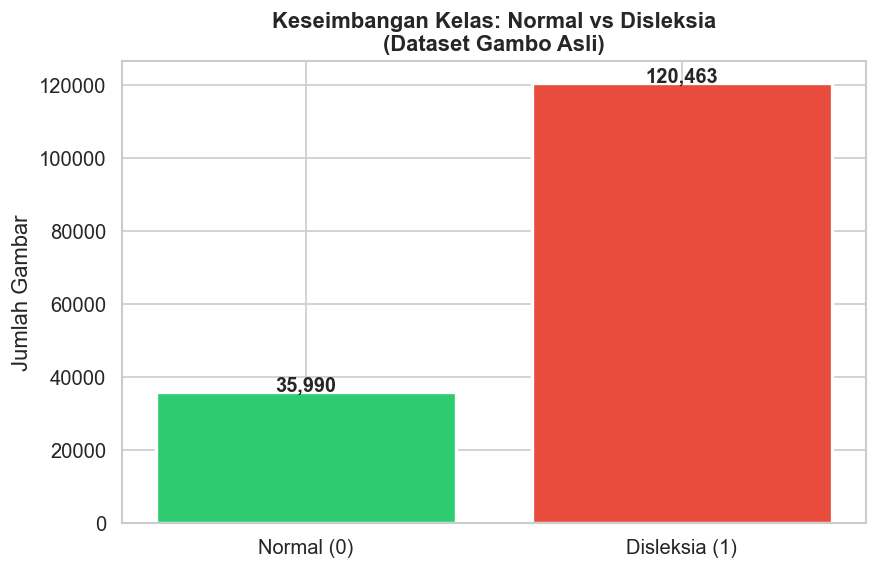

⚠️ PERINGATAN: Rasio Disleksia : Normal = 3.35 : 1


In [16]:
normal_count = len(df[df['folder_category'] == 'Normal'])
dys_count = len(df[df['folder_category'] != 'Normal'])

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(['Normal (0)', 'Disleksia (1)'], [normal_count, dys_count], color=['#2ecc71', '#e74c3c'], edgecolor='white', linewidth=2)

for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100, f'{int(bar.get_height()):,}', ha='center', fontweight='bold', fontsize=12)

ax.set_title('Keseimbangan Kelas: Normal vs Disleksia\n(Dataset Gambo Asli)', fontweight='bold')
ax.set_ylabel('Jumlah Gambar')
plt.show()

ratio = dys_count / normal_count if normal_count > 0 else 0
print(f'⚠️ PERINGATAN: Rasio Disleksia : Normal = {ratio:.2f} : 1')

**Insight 4.1:**
- Kelas `Normal` sangat sedikit jumlahnya, yang berpotensi menyebabkan model AI mengalami *majority class bias*.
- Dibutuhkan penambahan dataset kelas Normal dari sumber eksternal untuk menyeimbangkan rasio klasifikasi biner.

### 4.2 Distribusi Kelas per Split

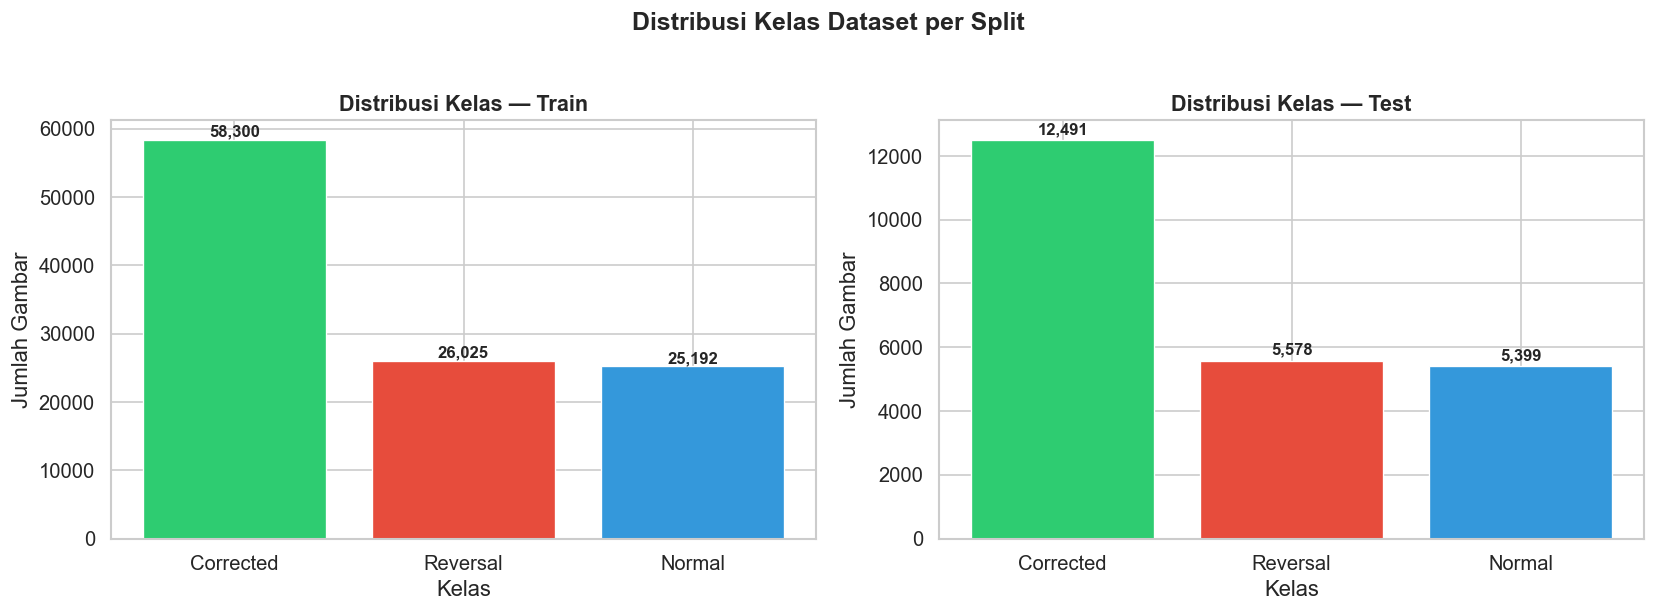

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for i, split in enumerate(['Train', 'Test']):
    data = df[df['split'] == split]['folder_category'].value_counts()
    colors = ['#2ecc71', '#e74c3c', '#3498db']
    bars = axes[i].bar(data.index, data.values, color=colors, edgecolor='white', linewidth=0.8)
    axes[i].set_title(f'Distribusi Kelas — {split}', fontweight='bold', fontsize=13)
    axes[i].set_ylabel('Jumlah Gambar')
    axes[i].set_xlabel('Kelas')
    for bar in bars:
        axes[i].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100, f'{int(bar.get_height()):,}', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.suptitle('Distribusi Kelas Dataset per Split', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

**Insight 4.2:**
- Proporsi relatif antar kelas (Normal, Corrected, Reversal) cukup konsisten baik pada set Train maupun Test.
- Tidak ditemukan *distribution shift* yang ekstrem, menandakan fungsi stratifikasi saat pemisahan dataset berjalan dengan baik.

### 4.3 Distribusi Severity Score

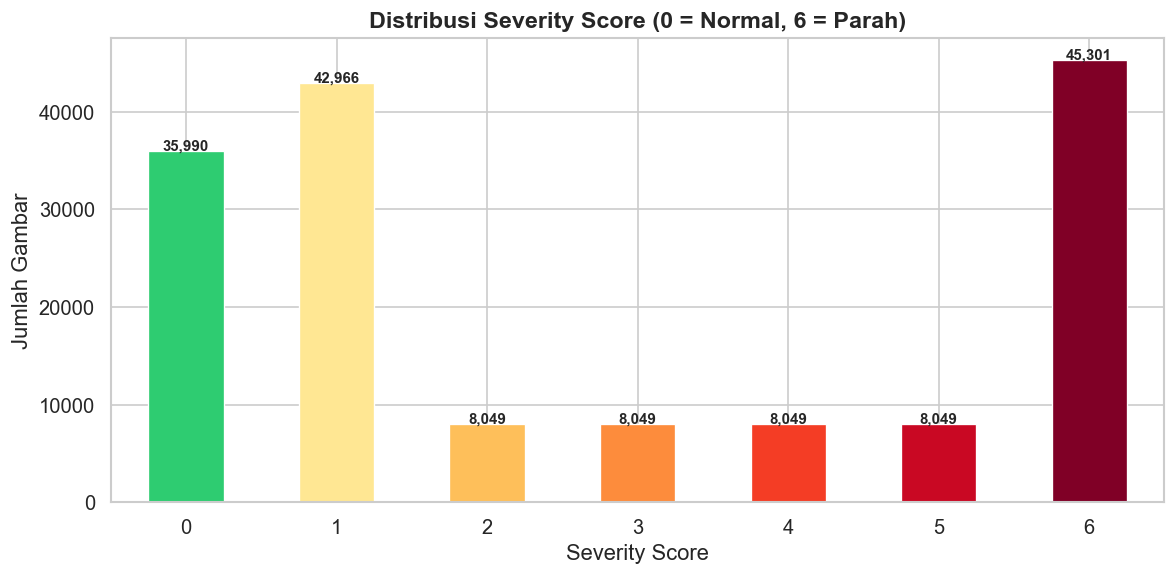

In [16]:
fig, ax = plt.subplots(figsize=(10, 5))
sev = df['severity_score'].value_counts().sort_index()
colors_sev = ['#2ecc71'] + [plt.cm.YlOrRd(i/6) for i in range(1,7)]
sev.plot(kind='bar', ax=ax, color=colors_sev[:len(sev)], edgecolor='white', linewidth=0.8)
ax.set_title('Distribusi Severity Score (0 = Normal, 6 = Parah)', fontweight='bold', fontsize=14)
ax.set_xlabel('Severity Score')
ax.set_ylabel('Jumlah Gambar')
ax.tick_params(axis='x', rotation=0)
for bar in ax.patches:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+100, f'{int(bar.get_height()):,}', ha='center', fontweight='bold', fontsize=9)
plt.tight_layout()
plt.show()

**Insight 4.3:**
- Distribusi Severity Score sangat bervariasi dan memusat pada skor yang tinggi (Skor 6).
- Skor `0` (Normal) memiliki jumlah yang tidak sebanding dengan total gabungan level keparahan disleksia.
- Ketimpangan severity ini harus menjadi catatan penting jika model akan dikembangkan untuk klasifikasi multi-kelas.
---

## 👁️ Bagian 2: Analisis Spasial & Piksel (Computer Vision Analytics)

### 4.4 Sampel Visual: Normal vs Corrected vs Reversal

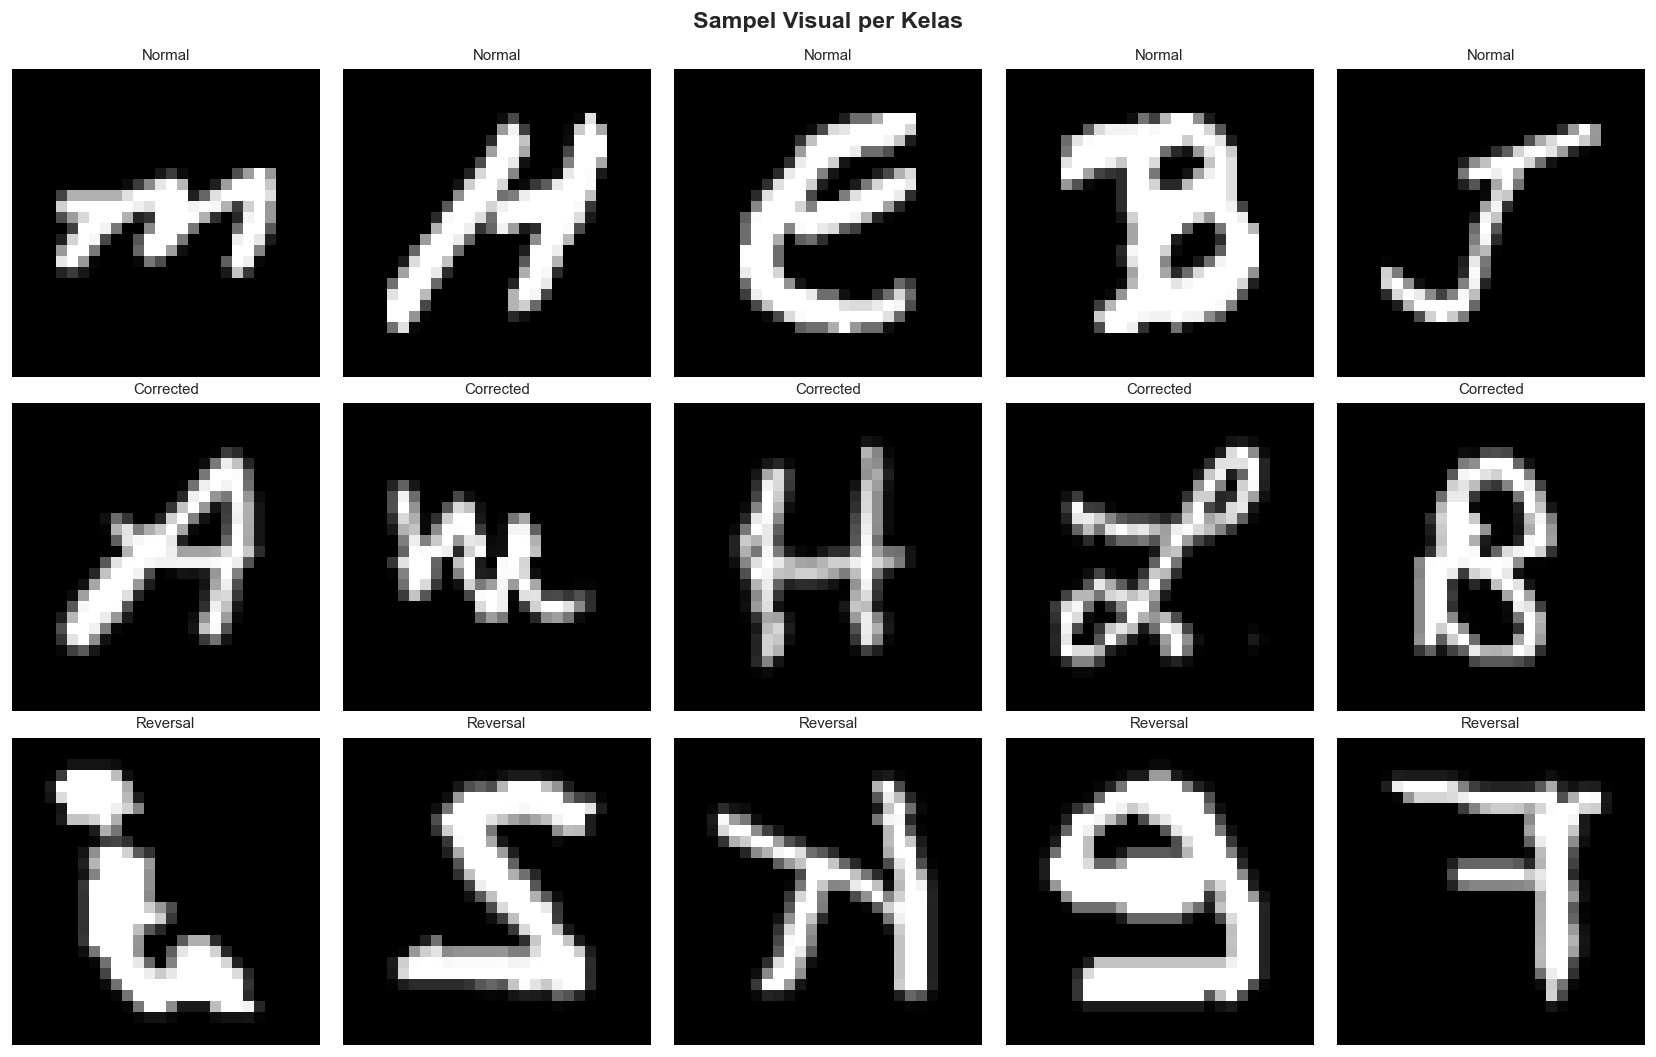

In [17]:
fig, axes = plt.subplots(3, 5, figsize=(14, 9))
categories = ['Normal', 'Corrected', 'Reversal']

for row, cat in enumerate(categories):
    subset = df[(df['folder_category'] == cat) & (df['split'] == 'Train')]
    samples = subset.sample(min(5, len(subset)), random_state=42)
    for col, (_, sample) in enumerate(samples.iterrows()):
        img_path = os.path.join('..', sample['image_path']) if not os.path.exists(sample['image_path']) else sample['image_path']
        try:
            img = Image.open(img_path).convert('L').resize((28,28))
            axes[row][col].imshow(np.array(img), cmap='gray')
        except: pass
        axes[row][col].set_title(f'{cat}', fontsize=9)
        axes[row][col].axis('off')

plt.suptitle('Sampel Visual per Kelas', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

**Insight 4.4:**
- **Normal:** Huruf terbentuk dengan satu goresan dominan yang tegas, bersih, dan mudah dikenali.
- **Corrected:** Goresan tampak tebal dan bertumpuk akibat tekanan pena berulang (*scribbling*), yang menjadi indikator keraguan menulis.
- **Reversal:** Huruf mengalami efek cermin (*mirror image*) atau rotasi yang tidak lazim, ciri khas utama dari disleksia orientasi spasial.

### 4.5. Pixel Variance Heatmap

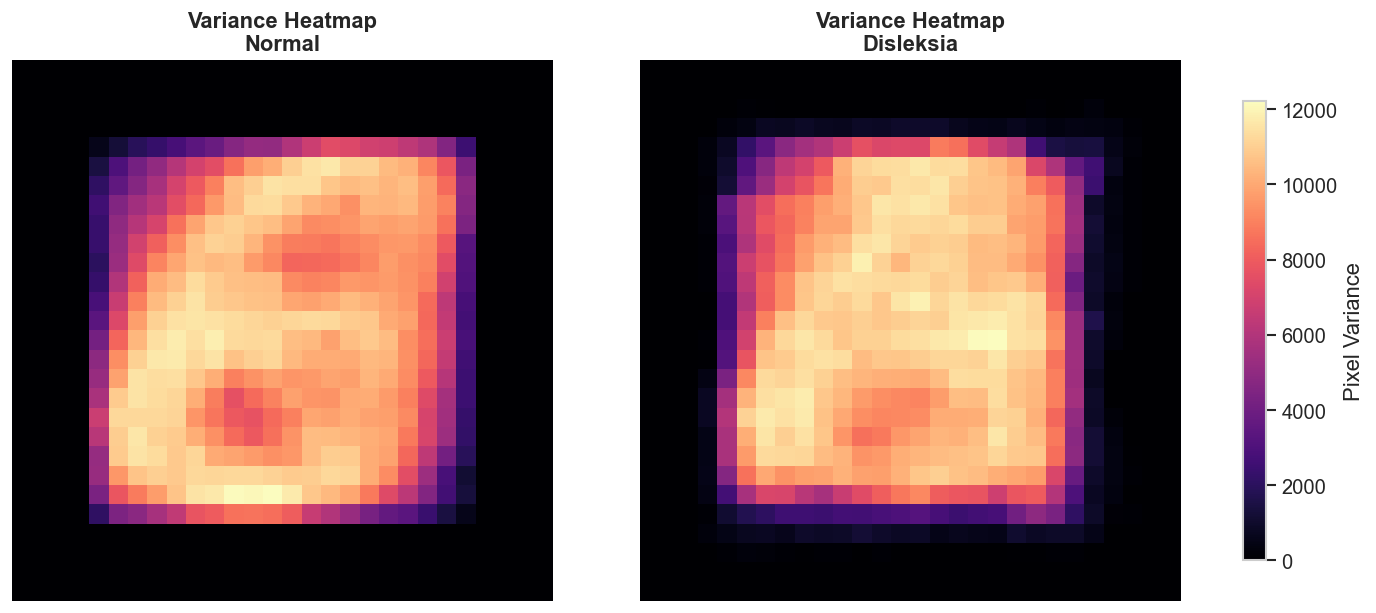

In [21]:
def compute_variance_image(subset, n=500):
    samples = subset.sample(min(n, len(subset)), random_state=42)
    arrays = []
    for _, row in samples.iterrows():
        p = row['image_path']
        if not os.path.exists(p): p = os.path.join('..', p)
        try:
            img = Image.open(p).convert('L').resize((28, 28))
            arrays.append(np.array(img, dtype=np.float32))
        except: continue
    return np.var(arrays, axis=0) if arrays else np.zeros((28, 28))

normal_var = compute_variance_image(df[df['target_class'] == 0])
dys_var = compute_variance_image(df[df['target_class'] == 1])

fig, axes = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)
im1 = axes[0].imshow(normal_var, cmap='magma'); axes[0].set_title('Variance Heatmap\nNormal', fontweight='bold'); axes[0].axis('off')
im2 = axes[1].imshow(dys_var, cmap='magma'); axes[1].set_title('Variance Heatmap\nDisleksia', fontweight='bold'); axes[1].axis('off')
cbar = fig.colorbar(im2, ax=axes, shrink=0.85); cbar.set_label('Pixel Variance', rotation=90)
plt.show()

**Insight 4.5:**
- Tulisan Normal memiliki variansi piksel yang rapat dan terpusat di tengah, menandakan tingginya konsistensi letak huruf.
- Kelas Disleksia menghasilkan area kuning (variansi tinggi) yang menyebar sangat luas, membuktikan letak goresan mereka sangat fluktuatif dan bergetar secara spasial.

### 4.6. Heatmap Rata-rata Piksel (Skor Terendah vs Tertinggi)

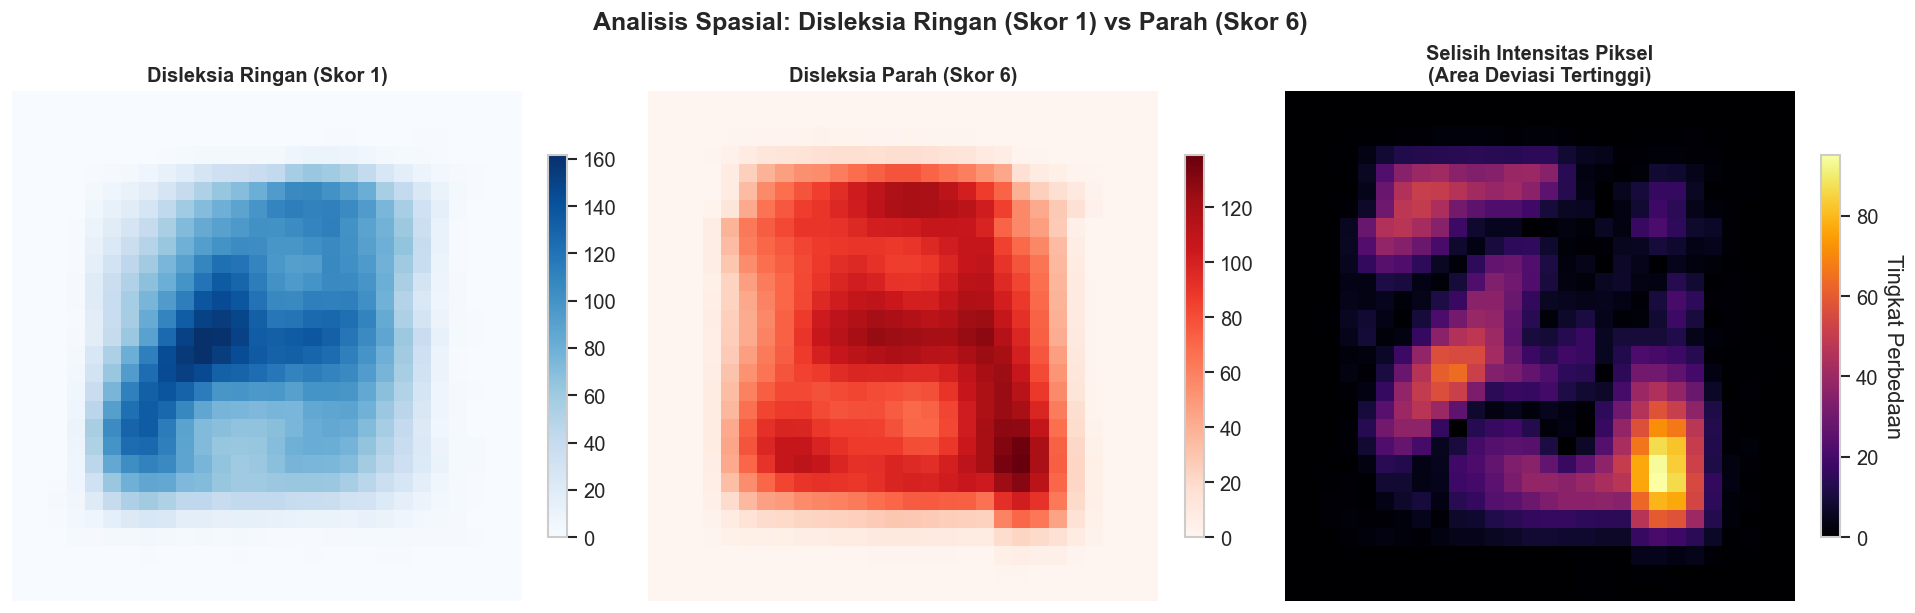

Rata-rata selisih intensitas: 11.32


In [3]:
def compute_mean_image_subset(subset, n=500):
    samples = subset.sample(min(n, len(subset)), random_state=42)
    arrays = []
    for _, row in samples.iterrows():
        p = row['image_path']
        if not os.path.exists(p): p = os.path.join('..', p)
        try:
            img = Image.open(p).convert('L').resize((28,28))
            arrays.append(np.array(img, dtype=np.float32))
        except: continue
    return np.mean(arrays, axis=0) if arrays else np.zeros((28,28))

dys = df[df['severity_score'] > 0]
if len(dys) > 0:
    min_s = dys['severity_score'].min()
    max_s = dys['severity_score'].max()
    mean_low = compute_mean_image_subset(dys[dys['severity_score']==min_s])
    mean_high = compute_mean_image_subset(dys[dys['severity_score']==max_s])
    diff = np.abs(mean_high - mean_low)

    fig, axes = plt.subplots(1, 3, figsize=(16, 5), constrained_layout=True)
    
    # 1. Skor Ringan
    im0 = axes[0].imshow(mean_low, cmap='Blues')
    axes[0].set_title(f'Disleksia Ringan (Skor {min_s})', fontweight='bold', fontsize=12)
    fig.colorbar(im0, ax=axes[0], shrink=0.75)
    
    # 2. Skor Parah
    im1 = axes[1].imshow(mean_high, cmap='Reds')
    axes[1].set_title(f'Disleksia Parah (Skor {max_s})', fontweight='bold', fontsize=12)
    fig.colorbar(im1, ax=axes[1], shrink=0.75)
    
    # 3. Selisih Intensitas (Difference)
    im2 = axes[2].imshow(diff, cmap='inferno')
    axes[2].set_title('Selisih Intensitas Piksel\n(Area Deviasi Tertinggi)', fontweight='bold', fontsize=12)
    cbar = fig.colorbar(im2, ax=axes[2], shrink=0.75)
    cbar.set_label('Tingkat Perbedaan', rotation=270, labelpad=15)
    
    for ax in axes: 
        ax.axis('off')
        
    plt.suptitle(f'Analisis Spasial: Disleksia Ringan (Skor {min_s}) vs Parah (Skor {max_s})', fontsize=15, fontweight='bold')
    plt.savefig('../assets/heatmap_emnist.png', dpi=200, bbox_inches='tight')
    plt.show()
    print(f'Rata-rata selisih intensitas: {np.mean(diff):.2f}')

**Insight 4.6:**
- Skor ringan (1) memiliki pola piksel rata-rata yang lebih tegas dan terkumpul di satu area.
- Skor parah (6) menunjukkan rata-rata piksel yang jauh lebih menyebar dan memudar, merepresentasikan tingginya variasi goresan dan inkonsistensi posisi huruf.
- Area dengan "Selisih Intensitas" (warna kuning cerah pada panel ketiga) menunjukkan zona anomali utama di mana huruf paling sering terdistorsi.
---

## 📐 Bagian 3: Validasi Fitur Ekstraksi Matematis (Feature Engineering)
*(Catatan: Visualisasi di bawah ini menggunakan DataFrame `features_df` yang diekstrak dari dataset)*


### 4.7. Stroke Density Analysis (Deteksi Over-tracing)

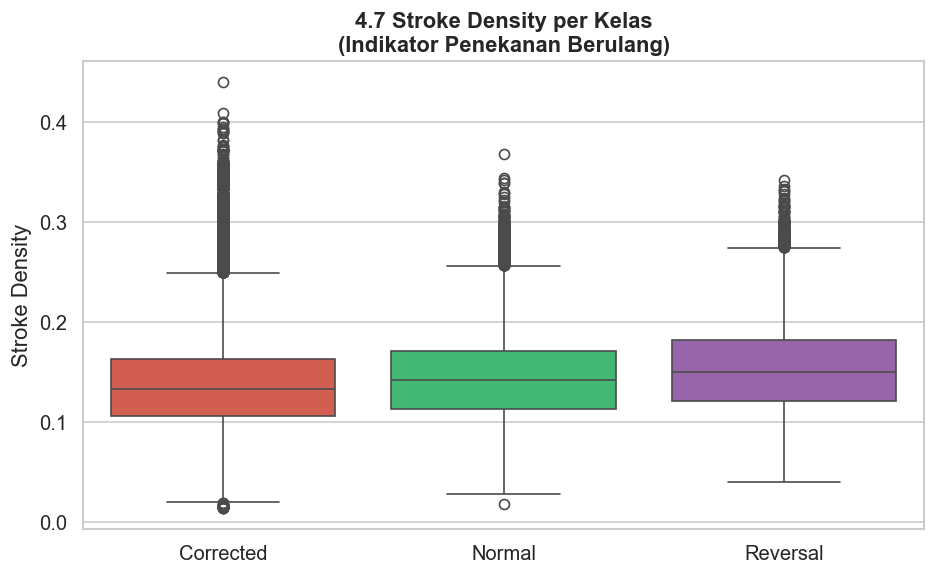

In [33]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(data=features_df, x='folder_category', y='stroke_density', hue='folder_category', palette={'Normal': '#2ecc71', 'Corrected': '#e74c3c', 'Reversal': '#9b59b6'}, ax=ax)
ax.set_title('4.7 Stroke Density per Kelas\n(Indikator Penekanan Berulang)', fontweight='bold')
ax.set_xlabel(''); ax.set_ylabel('Stroke Density')
plt.tight_layout()
plt.show()

**Insight 4.7:**
- Distribusi *Stroke Density* kelas Disleksia (terutama tipe *Corrected*) secara konsisten lebih tinggi dibanding Normal.
- Hal ini secara statistik memvalidasi fenomena *over-tracing* atau tekanan pena berlebih pada penderita disleksia.

### 4.8. Center of Mass Analysis (Distorsi Spasial)

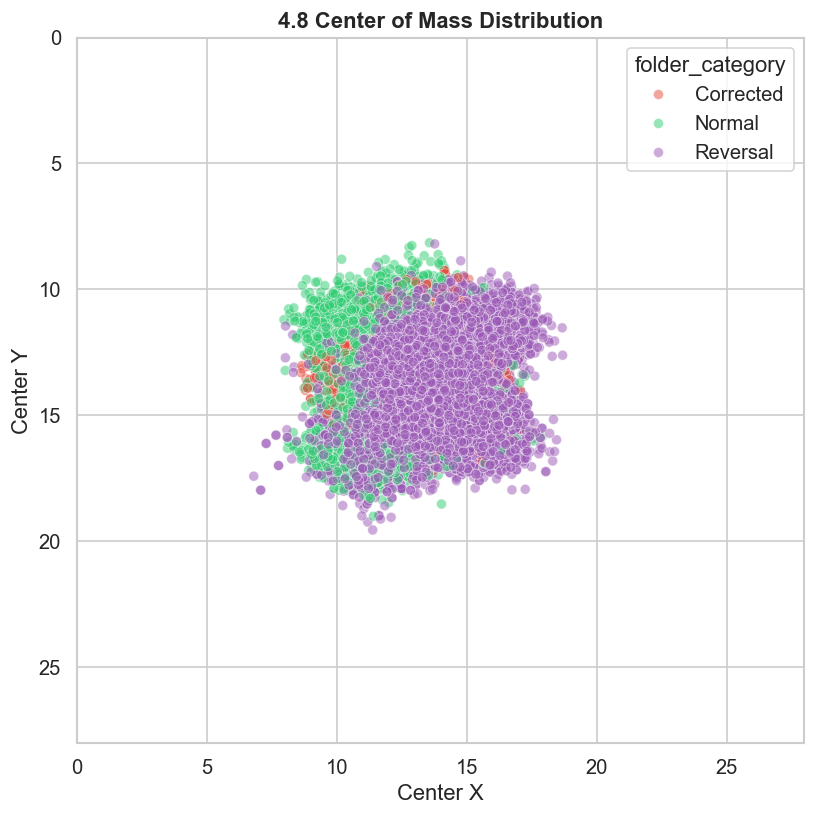

In [34]:
fig, ax = plt.subplots(figsize=(7, 7))
sns.scatterplot(data=features_df, x='center_of_mass_x', y='center_of_mass_y', hue='folder_category', palette={'Normal': '#2ecc71', 'Corrected': '#e74c3c', 'Reversal': '#9b59b6'}, alpha=0.5, ax=ax)
ax.set_title('4.8 Center of Mass Distribution', fontweight='bold')
ax.set_xlim(0, 28); ax.set_ylim(28, 0)
ax.set_xlabel('Center X'); ax.set_ylabel('Center Y')
plt.tight_layout()
plt.show()

**Insight 4.8:**
- Penderita disleksia tipe *Reversal* kerap memiliki titik *Center of Mass* yang sangat melenceng keluar dari sumbu utama.
- Fitur ini berguna untuk mendeteksi distorsi keruangan dan asimetri letak pada penulisan huruf.

### 4.9. Bounding Box Ratio (Proporsi Huruf)

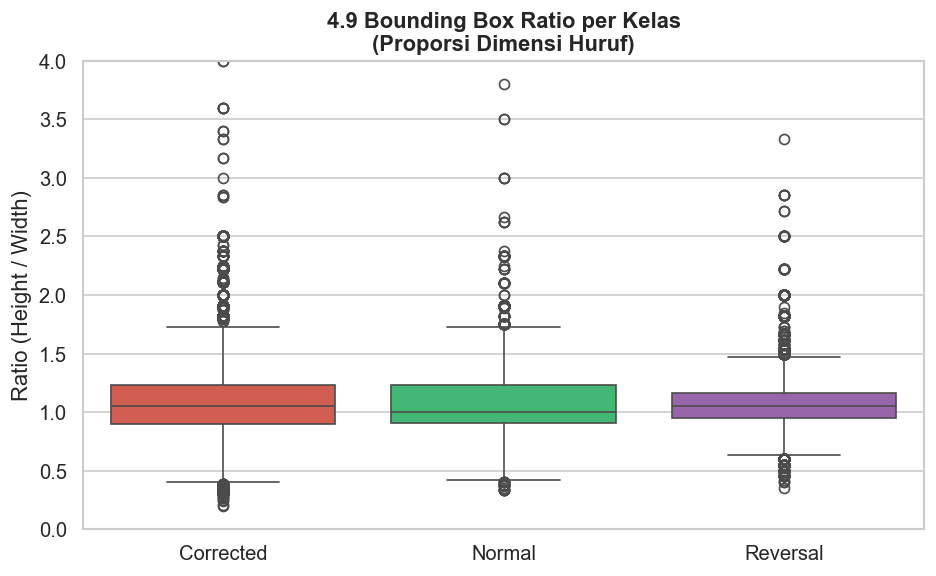

In [38]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(data=features_df, x='folder_category', y='bounding_box_ratio', hue='folder_category', palette={'Normal': '#2ecc71', 'Corrected': '#e74c3c', 'Reversal': '#9b59b6'}, ax=ax)
ax.set_title('4.9 Bounding Box Ratio per Kelas\n(Proporsi Dimensi Huruf)', fontweight='bold')
ax.set_xlabel(''); ax.set_ylabel('Ratio (Height / Width)')
ax.set_ylim(0, 4) 
plt.tight_layout()
plt.show()

**Insight 4.9:**
- Rasio dimensi (Tinggi/Lebar) untuk tulisan Normal lebih konsisten dan mendekati proporsi abjad ideal.
- Pada kasus Disleksia, huruf cenderung "gepeng" atau menyimpang secara ekstrem akibat goresan yang keluar batas (*out of bounds*).

### 4.10. Stroke Transitions (Deteksi Tremor)

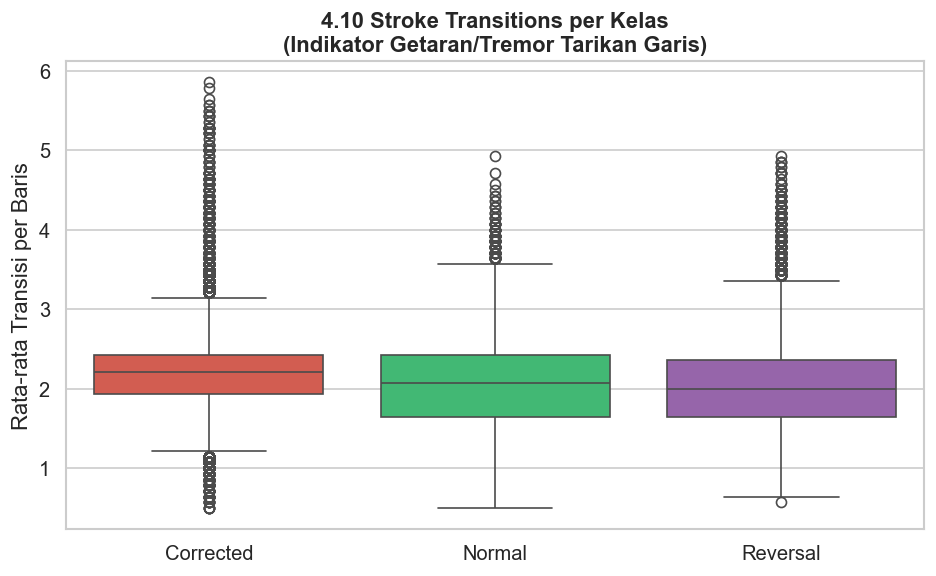

In [39]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(data=features_df, x='folder_category', y='stroke_transitions', hue='folder_category', palette={'Normal': '#2ecc71', 'Corrected': '#e74c3c', 'Reversal': '#9b59b6'}, ax=ax)
ax.set_title('4.10 Stroke Transitions per Kelas\n(Indikator Getaran/Tremor Tarikan Garis)', fontweight='bold')
ax.set_xlabel(''); ax.set_ylabel('Rata-rata Transisi per Baris')
plt.tight_layout()
plt.show()

**Insight 4.10:**
- Kotak distribusi (Boxplot) untuk kelas Disleksia terletak jauh di atas kelas Normal.
- Tingginya jumlah perpindahan warna (Hitam ke Putih) per baris membuktikan secara matematis keberadaan *tremor* atau tarikan garis yang tidak stabil.

### 4.11. Horizontal Symmetry Analysis (Deteksi Reversal)

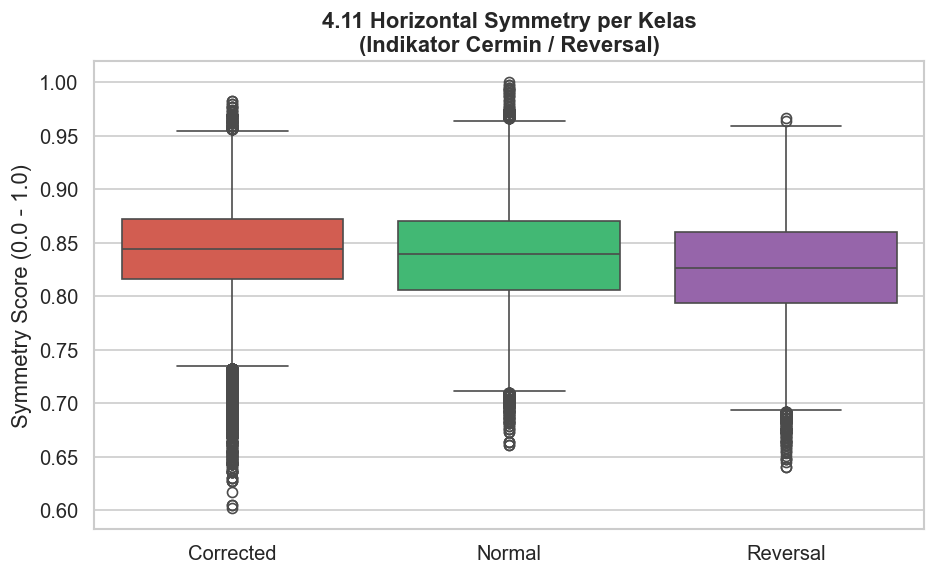

In [40]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(data=features_df, x='folder_category', y='horizontal_symmetry', hue='folder_category', palette={'Normal': '#2ecc71', 'Corrected': '#e74c3c', 'Reversal': '#9b59b6'}, ax=ax)
ax.set_title('4.11 Horizontal Symmetry per Kelas\n(Indikator Cermin / Reversal)', fontweight='bold')
ax.set_xlabel(''); ax.set_ylabel('Symmetry Score (0.0 - 1.0)')
plt.tight_layout()
plt.show()

**Insight 4.11:**
- Kelas *Reversal* menunjukkan pola anomali kesimetrisan yang paling jelas terpisah dari Normal.
- Fitur ini terbukti secara empiris menjadi *game changer* (indikator utama) dalam mendeteksi gejala pembalikan huruf efek cermin.

---
## 📋 Bagian 4: Visualisasi Explanatory — Menjawab Pertanyaan Bisn

Bagian ini secara eksplisit menjawab **empat pertanyaan bisnis utama** yang didefinisikan di awal notebook, menggunakan visualisasi dan analisis statistik sebagai bukti pendukung.

> **Berbeda dengan EDA di atas** (yang bersifat *exploratory* / mencari pola), bagian ini bersifat **explanatory** — menyajikan jawaban yang jelas dan terstruktur.

### Pertanyaan Bisnis 1: *"Apakah dataset asli (Gambo) sudah cukup representatif dan seimbang untuk melatih model AI?"*

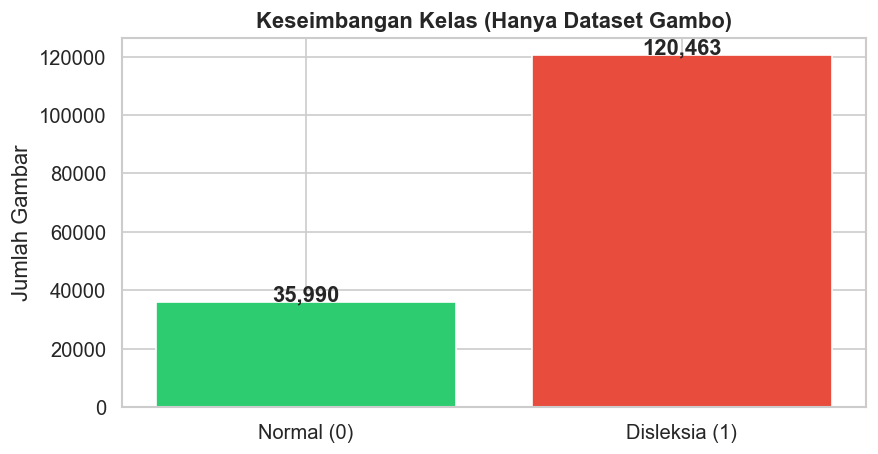

In [41]:
normal_count = len(df[df['folder_category'] == 'Normal'])
dys_count = len(df[df['folder_category'] != 'Normal'])

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(['Normal (0)', 'Disleksia (1)'], [normal_count, dys_count], color=['#2ecc71', '#e74c3c'])
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500, f'{int(bar.get_height()):,}', ha='center', fontweight='bold')

ax.set_title('Keseimbangan Kelas (Hanya Dataset Gambo)', fontweight='bold')
ax.set_ylabel('Jumlah Gambar')
plt.show()

> ❌ **KESIMPULAN: DATA SANGAT TIDAK SEIMBANG.** <br>
> Jika kita langsung melatih AI menggunakan dataset ini, model akan mengalami *majority class bias*. **Tindakan Lanjutan:** Kita wajib menyuntikkan dataset eksternal (EMNIST) untuk menambah populasi kelas Normal.

---

### Pertanyaan Bisnis 2: *"Apakah pola visual tulisan tangan cukup kuat merepresentasikan kondisi kognitif disleksia, atau sekadar indikasi ambigu?"*

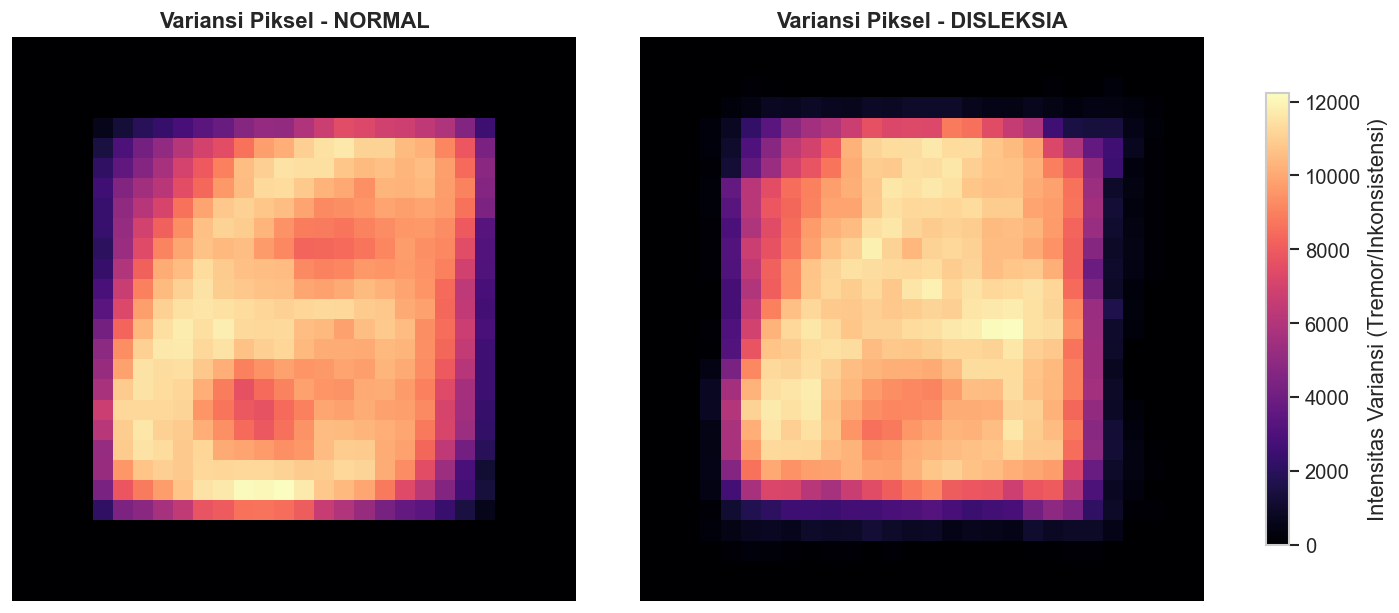

In [42]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)
im1 = axes[0].imshow(normal_var, cmap='magma'); axes[0].set_title('Variansi Piksel - NORMAL', fontweight='bold'); axes[0].axis('off')
im2 = axes[1].imshow(dys_var, cmap='magma'); axes[1].set_title('Variansi Piksel - DISLEKSIA', fontweight='bold'); axes[1].axis('off')
fig.colorbar(im2, ax=axes, shrink=0.8, label='Intensitas Variansi (Tremor/Inkonsistensi)')
plt.show()

> ✅ **KESIMPULAN: POLA VISUAL SANGAT KUAT DAN TIDAK AMBIGU.** <br>
> Area menyala (kuning) pada grafik *Variance Heatmap* kelas disleksia jauh lebih luas dan tidak beraturan, membuktikan secara empiris bahwa letak goresan penderita disleksia sangat tidak konsisten dibandingkan tulisan Normal.

---

### Pertanyaan Bisnis 3: *"Bagaimana merancang sistem AI yang tidak hanya akurat, tetapi mampu menjelaskan mengapa suatu tulisan terindikasi disleksia?"*

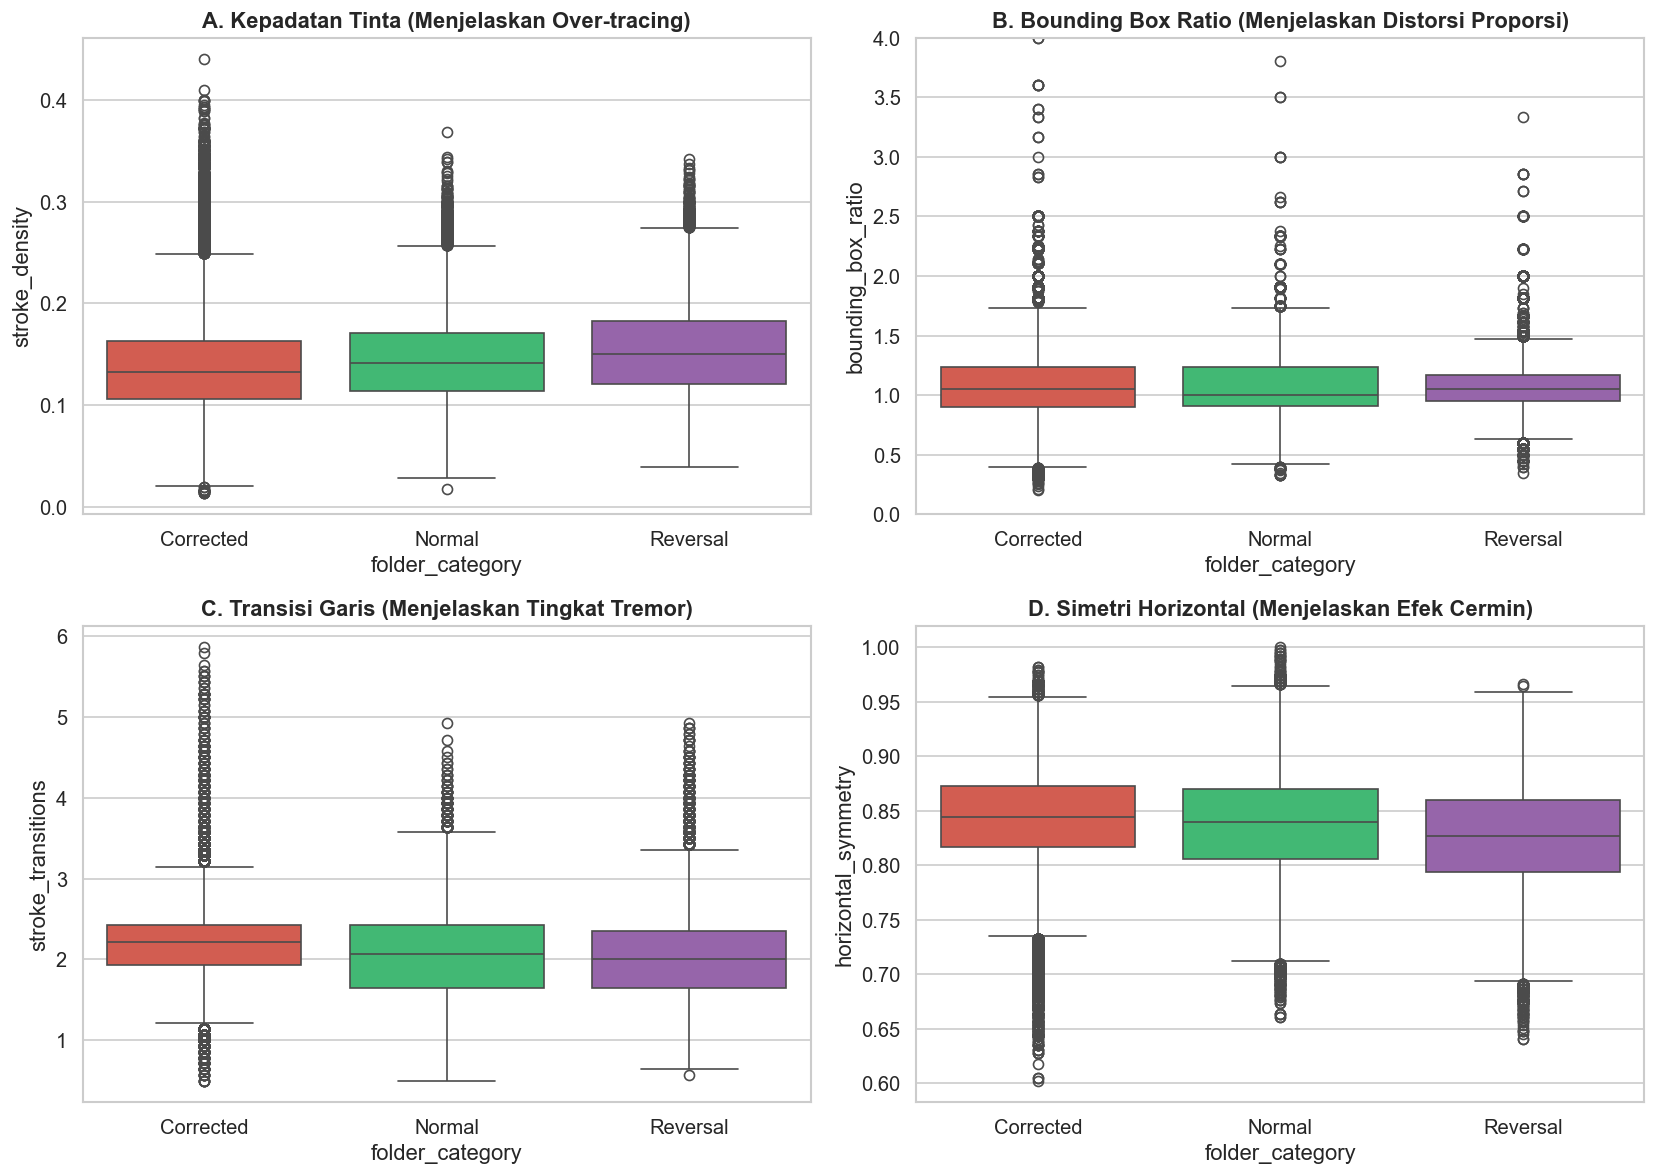

In [44]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
palette_colors = {'Normal': '#2ecc71', 'Corrected': '#e74c3c', 'Reversal': '#9b59b6'}

sns.boxplot(data=features_df, x='folder_category', y='stroke_density', hue='folder_category', palette=palette_colors, ax=axes[0,0])
axes[0,0].set_title('A. Kepadatan Tinta (Menjelaskan Over-tracing)', fontweight='bold')

sns.boxplot(data=features_df, x='folder_category', y='bounding_box_ratio', hue='folder_category', palette=palette_colors, ax=axes[0,1])
axes[0,1].set_title('B. Bounding Box Ratio (Menjelaskan Distorsi Proporsi)', fontweight='bold'); axes[0,1].set_ylim(0, 4)

sns.boxplot(data=features_df, x='folder_category', y='stroke_transitions', hue='folder_category', palette=palette_colors, ax=axes[1,0])
axes[1,0].set_title('C. Transisi Garis (Menjelaskan Tingkat Tremor)', fontweight='bold')

sns.boxplot(data=features_df, x='folder_category', y='horizontal_symmetry', hue='folder_category', palette=palette_colors, ax=axes[1,1])
axes[1,1].set_title('D. Simetri Horizontal (Menjelaskan Efek Cermin)', fontweight='bold')

plt.tight_layout()
plt.show()

> ✅ **KESIMPULAN: DENGAN PENDEKATAN LATE FUSION.** <br>
> Seperti yang terlihat pada Boxplot, fitur-fitur matematis ini mampu memisahkan kelas secara organik. AI kelak dapat menyertakan angka-angka klinis ini sebagai rasionalisasi logis atas prediksinya.

---

### Pertanyaan Bisnis 4: *"Bagaimana sistem dapat memberikan interpretasi klinis terhadap hasil prediksi klasifikasinya?"*

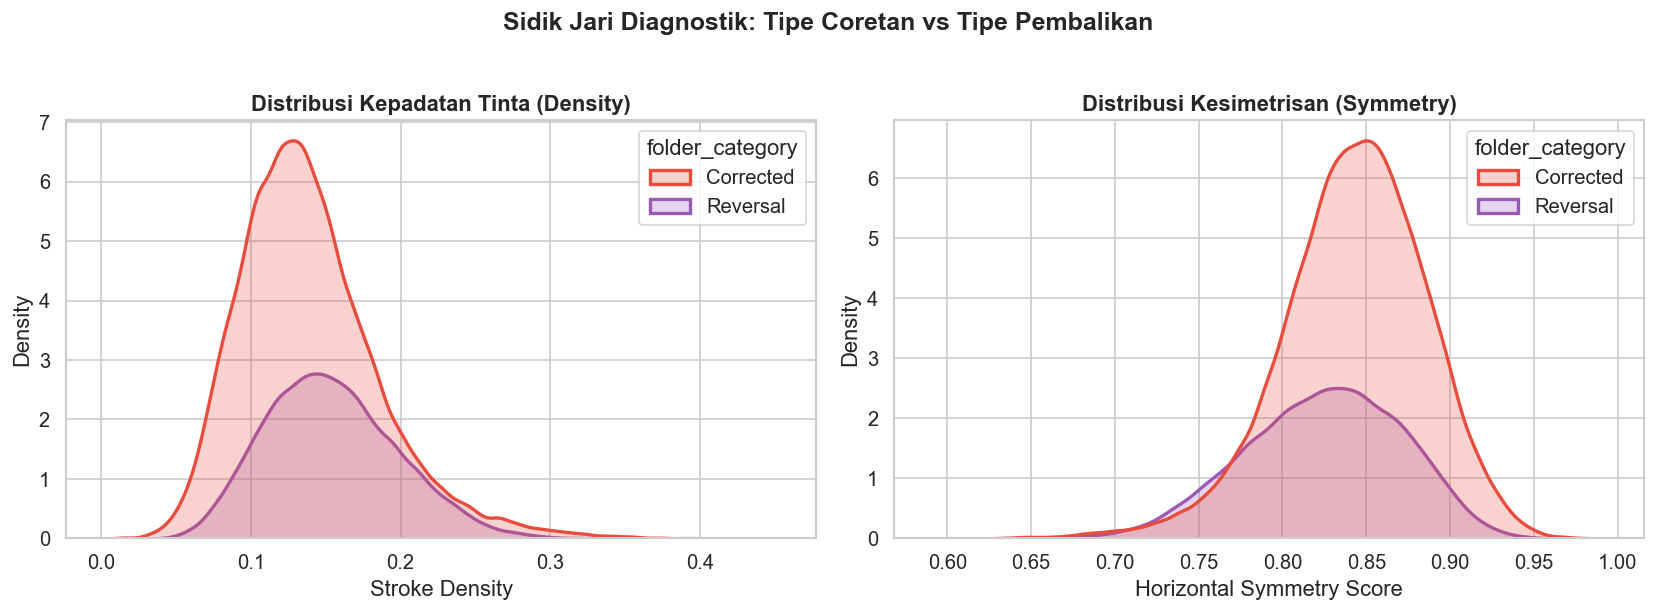

In [45]:
dys_subtype_df = features_df[features_df['folder_category'].isin(['Corrected', 'Reversal'])]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
subtype_colors = {'Corrected': '#e74c3c', 'Reversal': '#9b59b6'}

sns.kdeplot(data=dys_subtype_df, x='stroke_density', hue='folder_category', fill=True, palette=subtype_colors, ax=axes[0], linewidth=2)
axes[0].set_title('Distribusi Kepadatan Tinta (Density)', fontweight='bold'); axes[0].set_xlabel('Stroke Density')

sns.kdeplot(data=dys_subtype_df, x='horizontal_symmetry', hue='folder_category', fill=True, palette=subtype_colors, ax=axes[1], linewidth=2)
axes[1].set_title('Distribusi Kesimetrisan (Symmetry)', fontweight='bold'); axes[1].set_xlabel('Horizontal Symmetry Score')

plt.suptitle('Sidik Jari Diagnostik: Tipe Coretan vs Tipe Pembalikan', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

> ✅ **KESIMPULAN: MELALUI PROFILING SUB-TIPE DISLEKSIA.** <br>
> AI mampu memberikan interpretasi mendalam karena setiap sub-tipe disleksia terbukti memiliki "sidik jari" numerik (KDE Plot). Model kelak mampu memberikan laporan sub-tipe disleksia spesifik, bukan sekadar prediksi "Sakit/Sehat".

---

### 🏆 Kesimpulan Explanatory Analysis

| Pertanyaan Bisnis / RQ | Jawaban | Bukti |
|---|---|---|
| **[Data Readiness]** Apakah dataset asli seimbang? | ❌ **Tidak** | Bar chart proporsi kelas (Imbalance Fatal) |
| **[RQ 1]** Apakah pola visual disleksia nyata? | ✅ **Ya** | Variance Heatmap (Area tremor/inkonsistensi) |
| **[RQ 2]** Dapatkah AI menjelaskan keputusannya? | ✅ **Ya** | Distribusi Boxplot dari 6 Fitur Matematis |
| **[RQ 6]** Dapatkah AI membedakan sub-tipe disleksia? | ✅ **Ya** | KDE Plot sidik jari *Corrected* vs *Reversal* |

**Implikasi & Keputusan Eksekusi (Tindakan Lanjutan):**
1. Ekstraksi **6 Fitur Matematis** terbukti sangat valid dan memisahkan kelas dengan baik. Kita resmi akan menggunakan pendekatan *Late Fusion*.
2. **NAMUN**, arsitektur AI secanggih apa pun akan gagal dan bias jika dilatih pada data cacat ini (*Imbalance*). 
3. **Keputusan Final:** Proses *modeling* di-pause. Kita **WAJIB** berpindah ke *notebook* baru untuk mengintegrasikan dataset EMNIST (huruf normal) demi menambal ketimpangan kelas yang sangat parah ini.

---
# Tahap 5: Stratified Split & Persiapan Handover

Tahap ini membagi data bersih menjadi **3 set** (Train / Validation / Test) dan menyiapkan seluruh informasi yang dibutuhkan AI Engineer.

### A. Stratified Split & Final CSV

Kode berikut digunakan untuk membagi dataset menjadi:
- Train (70%)
- Validation (15%)
- Test (15%)

Split dilakukan menggunakan **stratified sampling** berdasarkan `severity_score` agar distribusi kelas tetap seimbang di setiap subset.

Pipeline juga membuat:
- `unique_filename`
- label split final
- `master_dataset_final.csv`

Duplikasi nama file akan otomatis ditangani dengan penambahan suffix (`_2`, `_3`, dst).

In [ ]:
"""
RE-SPLIT FINAL DATASET
Untuk master_dataset_final_rill.csv
+ stratified split ulang
+ rebuild unique_filename
"""

import os
import pandas as pd

from sklearn.model_selection import train_test_split

# ============================================================
# CONFIG
# ============================================================

CSV_INPUT = 'master_dataset_final_rill.csv'

CSV_OUTPUT = 'master_dataset_final_balanced.csv'

TRAIN_RATIO = 0.70
VAL_RATIO   = 0.15
TEST_RATIO  = 0.15

RANDOM_STATE = 42

# ============================================================
# LOAD DATA
# ============================================================

print('=' * 60)

print('MEMBACA FINAL CSV')

df = pd.read_csv(CSV_INPUT)

print(f'Total baris : {len(df):,}')

required = [
    'image_path',
    'file_name',
    'folder_category',
    'severity_score',
    'target_class'
]

for col in required:

    if col not in df.columns:

        raise ValueError(
            f'Kolom "{col}" tidak ditemukan!'
        )

# ============================================================
# STRATIFIED SPLIT
# ============================================================

print('\nMELAKUKAN RE-SPLIT DATASET')

df_train_val, df_test = train_test_split(
    df,
    test_size=TEST_RATIO,
    random_state=RANDOM_STATE,
    stratify=df['severity_score']
)

val_ratio_of_train_val = (
    VAL_RATIO / (TRAIN_RATIO + VAL_RATIO)
)

df_train, df_val = train_test_split(
    df_train_val,
    test_size=val_ratio_of_train_val,
    random_state=RANDOM_STATE,
    stratify=df_train_val['severity_score']
)

# ============================================================
# ASSIGN SPLIT
# ============================================================

df_train = df_train.copy()
df_val   = df_val.copy()
df_test  = df_test.copy()

df_train['split'] = 'Train'

df_val['split'] = 'Validation'

df_test['split'] = 'Test'

# ============================================================
# COMBINE
# ============================================================

df_final = pd.concat(
    [df_train, df_val, df_test],
    ignore_index=True
)

# ============================================================
# REBUILD UNIQUE FILENAME
# ============================================================

print('\nMEMBUAT UNIQUE FILENAME')

new_names = []

# counter per split + category + severity
folder_counters = {}

for _, row in df_final.iterrows():

    split_name = row['split']

    category = row['folder_category']

    original_name = os.path.basename(
        row['file_name']
    )

    stem, ext = os.path.splitext(original_name)

    ext = ext if ext else '.png'

    # ========================================================
    # HAPUS PREFIX SPLIT LAMA
    # ========================================================

    parts = stem.split('_')

    if (
        len(parts) >= 3
        and parts[0] in ['Train', 'Validation', 'Test']
    ):

        stem = '_'.join(parts[2:])

    # ========================================================
    # NORMAL → BIARKAN ASLI
    # ========================================================

    if category == 'Normal':

        final_name = (
            f'{split_name}_'
            f'{category}_'
            f'{stem}{ext}'
        )

    # ========================================================
    # CORRECTED / REVERSAL
    # ========================================================

    else:

        # contoh:
        # 1_2 -> severity = 1

        if '_' in stem:

            severity = stem.split('_')[0]

        else:

            severity = stem

        key = (
            split_name,
            category,
            severity
        )

        if key not in folder_counters:

            folder_counters[key] = 1

        number = folder_counters[key]

        folder_counters[key] += 1

        final_name = (
            f'{split_name}_'
            f'{category}_'
            f'{severity}_'
            f'{number:05d}{ext}'
        )

    new_names.append(final_name)

df_final['unique_filename'] = new_names

print(f'✅ {len(df_final):,} unique filename selesai dibuat.')

# ============================================================
# SAVE CSV
# ============================================================

df_final.to_csv(
    CSV_OUTPUT,
    index=False
)

# ============================================================
# REPORT
# ============================================================

print('\n=== HASIL FINAL SPLIT ===')

total = len(df_final)

for split in ['Train', 'Validation', 'Test']:

    n = len(
        df_final[
            df_final['split'] == split
        ]
    )

    print(
        f'{split:12s}: {n:>8,} ({n/total*100:.1f}%)'
    )

print(f'{"TOTAL":12s}: {total:>8,}')

print(f'\nCSV disimpan:')
print(CSV_OUTPUT)

# ============================================================
# DISTRIBUSI SEVERITY
# ============================================================

print('\n=== DISTRIBUSI SEVERITY ===')

severity_summary = pd.crosstab(
    df_final['split'],
    df_final['severity_score']
)

print(severity_summary)

print('\n✅ Re-split selesai.')

MEMBACA FINAL CSV
Total baris : 156,453

MELAKUKAN RE-SPLIT DATASET

MEMBUAT UNIQUE FILENAME
✅ 156,453 unique filename selesai dibuat.

=== HASIL FINAL SPLIT ===
Train       :  109,517 (70.0%)
Validation  :   23,468 (15.0%)
Test        :   23,468 (15.0%)
TOTAL       :  156,453

CSV disimpan:
master_dataset_final_balanced.csv

=== DISTRIBUSI SEVERITY ===
severity_score      0      1     2     3     4     5      6
split                                                      
Test             5399   6445  1207  1207  1208  1207   6795
Train           25192  30076  5635  5635  5634  5634  31711
Validation       5399   6445  1207  1207  1207  1208   6795

✅ Re-split selesai.


### B. Build Struktur Dataset Final

Kode berikut digunakan untuk membuat struktur dataset final berdasarkan `master_dataset_final.csv`.

Pipeline akan:
- membuat folder `Train / Validation / Test`,
- menyalin atau memindahkan file gambar,
- menggunakan `unique_filename`,
- lalu memverifikasi jumlah file hasil output.

Struktur akhir dataset:

```text
Dataset/Gambo_balanced/
├── Train/
│   ├── Normal/
│   ├── Corrected/
│   └── Reversal/
├── Validation/
│   ├── Normal/
│   ├── Corrected/
│   └── Reversal/
└── Test/
    ├── Normal/
    ├── Corrected/
    └── Reversal/
```

In [10]:
"""
COPY FINAL BALANCED DATASET
Dari:
    Dataset/Gambo_hapusPutihFinal

Ke:
    Dataset/Gambo_Balanced

Berdasarkan:
    master_dataset_final_balanced.csv
"""

import os
import shutil
import pandas as pd

# ============================================================
# CONFIG
# ============================================================

CSV_PATH = 'master_dataset_final_balanced.csv'

SOURCE_ROOT = r'Dataset/Gambo_hapusPutihFinal'

OUTPUT_ROOT = r'Dataset/Gambo_Balanced'

COPY_MODE = True   # True = copy | False = move

# ============================================================
# LOAD CSV
# ============================================================

print('=' * 60)

print('MEMBACA CSV FINAL')

df = pd.read_csv(CSV_PATH)

print(f'Total baris : {len(df):,}')

required = [
    'image_path',
    'file_name',
    'folder_category',
    'split',
    'unique_filename'
]

for col in required:

    if col not in df.columns:

        raise ValueError(
            f'Kolom "{col}" tidak ditemukan!'
        )

# ============================================================
# COPY FILE
# ============================================================

processed = 0
missing = 0
errors = 0

print('\nMEMULAI PROSES COPY...\n')

for _, row in df.iterrows():

    src = row['image_path']

    split_name = row['split']

    category = row['folder_category']

    unique_name = row['unique_filename']

    # ========================================================
    # VALIDASI SOURCE
    # ========================================================

    if not os.path.exists(src):

        # fallback jika path lama tidak valid
        src = os.path.join(
            SOURCE_ROOT,
            split_name,
            category,
            row['file_name']
        )

    if not os.path.exists(src):

        print(f'[MISSING] {src}')

        missing += 1

        continue

    # ========================================================
    # DESTINATION
    # ========================================================

    dst_dir = os.path.join(
        OUTPUT_ROOT,
        split_name,
        category
    )

    os.makedirs(
        dst_dir,
        exist_ok=True
    )

    dst = os.path.join(
        dst_dir,
        unique_name
    )

    # ========================================================
    # COPY / MOVE
    # ========================================================

    try:

        if COPY_MODE:

            shutil.copy2(src, dst)

        else:

            shutil.move(src, dst)

        processed += 1

        if processed % 5000 == 0:

            print(f'Processed: {processed:,}')

    except Exception as e:

        errors += 1

        print(f'[ERROR] {src} -> {e}')

# ============================================================
# VERIFY
# ============================================================

print('\n=== VERIFIKASI ===')

total_output = 0

for root, _, files in os.walk(OUTPUT_ROOT):

    total_output += len([
        f for f in files
        if f.lower().endswith('.png')
    ])

print(f'CSV rows      : {len(df):,}')

print(f'Output files  : {total_output:,}')

if len(df) == total_output:

    print('✅ JUMLAH SESUAI')

else:

    print('⚠️ JUMLAH TIDAK SESUAI')

# ============================================================
# SUMMARY
# ============================================================

print('\n=== RINGKASAN ===')

print(f'Berhasil : {processed:,}')

print(f'Missing  : {missing:,}')

print(f'Error    : {errors:,}')

print(f'\nOutput folder:')
print(os.path.abspath(OUTPUT_ROOT))

print('\n✅ Dataset balanced selesai dibuat.')

MEMBACA CSV FINAL
Total baris : 156,453

MEMULAI PROSES COPY...

Processed: 5,000
Processed: 10,000
Processed: 15,000
Processed: 20,000
Processed: 25,000
Processed: 30,000
Processed: 35,000
Processed: 40,000
Processed: 45,000
Processed: 50,000
Processed: 55,000
Processed: 60,000
Processed: 65,000
Processed: 70,000
Processed: 75,000
Processed: 80,000
Processed: 85,000
Processed: 90,000
Processed: 95,000
Processed: 100,000
Processed: 105,000
Processed: 110,000
Processed: 115,000
Processed: 120,000
Processed: 125,000
Processed: 130,000
Processed: 135,000
Processed: 140,000
Processed: 145,000
Processed: 150,000
Processed: 155,000

=== VERIFIKASI ===
CSV rows      : 156,453
Output files  : 156,453
✅ JUMLAH SESUAI

=== RINGKASAN ===
Berhasil : 156,453
Missing  : 0
Error    : 0

Output folder:
d:\Tugas\Kuliah\Semester 6\Dicoding\Capstone Project\Dataset Disleksia\notebooks\Dataset\Gambo_Balanced

✅ Dataset balanced selesai dibuat.


### C. Rebuild CSV Dataset Final

Kode berikut digunakan untuk membangun ulang metadata CSV dari dataset final yang sudah melalui proses split, cleaning, dan redistribusi duplicate.

Pipeline akan:
- membaca struktur dataset final,
- menghapus prefix split (`Train_`, `Test_`, dll) untuk validasi nama asli,
- menerapkan ulang filter regex,
- membuat `severity_score`,
- lalu menghasilkan `master_dataset_final_rill.csv`.

Tahap ini memastikan metadata akhir benar-benar sinkron dengan isi dataset final yang akan digunakan untuk training model.

In [12]:
import os
import re
import pandas as pd

from pathlib import Path

# ============================================================
# CONFIG
# ============================================================

root_dir = r'Dataset/Gambo_Balanced'

output_csv = 'master_dataset_final_balanced_rill.csv'

SCORE_MAP_ORIGINAL = {
    1: 6,
    4: 6,
    5: 5,
    6: 4,
    7: 3,
    8: 2,
    9: 1
}

# ============================================================
# REGEX FILTER
# ============================================================

RE_DUPLICATE_WIN = re.compile(r'\(\d+\)')
RE_PLACEHOLDER = re.compile(
    r'^(Normal|Reversal|Corrected)\.png$',
    re.IGNORECASE
)

RE_GLITCH = re.compile(r'\.qNcy', re.IGNORECASE)

RE_ALPHA_ONLY = re.compile(r'^[A-Za-z]\.png$')

RE_NORMAL_NUMBER = re.compile(r'^Normal\d+', re.IGNORECASE)

RE_REVERSAL_NUMBER = re.compile(r'^Reversal\d+', re.IGNORECASE)

RE_STARTS_WITH_ALPHA = re.compile(r'^[A-Za-z][-_.]')

# ============================================================
# SCAN DATASET
# ============================================================

print('Scanning dataset...\n')

data = []

filtered_out = {
    'duplicate': 0,
    'placeholder': 0,
    'glitch': 0,
    'alpha_only': 0,
    'normal_number': 0,
    'reversal_number': 0,
    'starts_alpha': 0,
    'missing_file': 0
}

processed = 0

for root, dirs, files in os.walk(root_dir):

    for file in files:

        if not file.lower().endswith('.png'):
            continue

        processed += 1

        if processed % 10000 == 0:
            print(f'Processed: {processed:,}')

        parts = Path(root).parts

        try:
            split_type = parts[-2]
            category = parts[-1]
        except:
            continue

        # ====================================================
        # STRIP PREFIX
        # ====================================================
        
        prefix = f"{split_type}_{category}_"
        if file.startswith(prefix):
            original_filename = file[len(prefix):]
        else:
            original_filename = file

        # ====================================================
        # FILTER
        # ====================================================

        if RE_DUPLICATE_WIN.search(original_filename):
            filtered_out['duplicate'] += 1
            continue

        if RE_GLITCH.search(original_filename):
            filtered_out['glitch'] += 1
            continue

        if RE_PLACEHOLDER.match(original_filename):
            filtered_out['placeholder'] += 1
            continue

        if category in ['Corrected', 'Reversal'] and RE_ALPHA_ONLY.match(original_filename):
            filtered_out['alpha_only'] += 1
            continue

        if category == 'Normal' and RE_NORMAL_NUMBER.match(original_filename):
            filtered_out['normal_number'] += 1
            continue

        if category == 'Reversal' and RE_REVERSAL_NUMBER.match(original_filename):
            filtered_out['reversal_number'] += 1
            continue

        if category in ['Corrected', 'Reversal'] and RE_STARTS_WITH_ALPHA.match(original_filename):
            filtered_out['starts_alpha'] += 1
            continue

        # ====================================================
        # VALIDASI FILE
        # ====================================================

        path_full = os.path.normpath(os.path.join(root, file))

        if not os.path.exists(path_full):
            filtered_out['missing_file'] += 1
            continue

        # ====================================================
        # SAVE ROW
        # ====================================================

        data.append({
            'image_path': path_full,
            'file_name': file,
            'original_filename': original_filename,
            'split': split_type,
            'folder_category': category
        })

# ============================================================
# DATAFRAME
# ============================================================

df = pd.DataFrame(data)

print(f'\nTotal kandidat bersih: {len(df):,}')

# ============================================================
# LABELING
# ============================================================

def get_score(row):

    filename = row['original_filename']
    folder = row['folder_category']

    # mismatch
    if 'Normal' in filename and folder != 'Normal':
        return 'DROP'

    # normal
    if folder == 'Normal':
        return 0

    # corrected/reversal
    if folder in ['Corrected', 'Reversal']:

        for sep in ['_', '-']:

            if sep in filename:

                prefix = filename.split(sep)[0]

                if prefix.isdigit():

                    val = int(prefix)

                    if 1 <= val <= 6:
                        return val

                    elif val in SCORE_MAP_ORIGINAL:
                        return SCORE_MAP_ORIGINAL[val]

                break

    return 'DROP'

# ============================================================
# APPLY SCORE
# ============================================================

df['severity_score'] = df.apply(get_score, axis=1)

dropped_by_score = len(
    df[df['severity_score'].astype(str) == 'DROP']
)

print(f'\nDropped by get_score: {dropped_by_score:,}')

# ============================================================
# CLEAN FINAL
# ============================================================

df_clean = df[
    ~df['severity_score'].astype(str).str.contains('DROP')
].copy()

df_clean['severity_score'] = df_clean['severity_score'].astype(int)

df_clean['target_class'] = df_clean['severity_score'].apply(
    lambda x: 0 if x == 0 else 1
)

# ============================================================
# SAVE CSV
# ============================================================

df_clean.drop(columns=['original_filename'], inplace=True, errors='ignore')
df_clean.to_csv(output_csv, index=False)

# ============================================================
# SUMMARY
# ============================================================

print('\n=== FILTER SUMMARY ===')

for k, v in filtered_out.items():
    print(f'{k:20s}: {v:,}')

print(f'\nFinal dataset: {len(df_clean):,} rows')

print(f'\nCSV saved:')
print(output_csv)

print('\nContoh data:')
print(df_clean.sample(5))

Scanning dataset...

Processed: 10,000
Processed: 20,000
Processed: 30,000
Processed: 40,000
Processed: 50,000
Processed: 60,000
Processed: 70,000
Processed: 80,000
Processed: 90,000
Processed: 100,000
Processed: 110,000
Processed: 120,000
Processed: 130,000
Processed: 140,000
Processed: 150,000

Total kandidat bersih: 156,453

Dropped by get_score: 0

=== FILTER SUMMARY ===
duplicate           : 0
placeholder         : 0
glitch              : 0
alpha_only          : 0
normal_number       : 0
reversal_number     : 0
starts_alpha        : 0
missing_file        : 0

Final dataset: 156,453 rows

CSV saved:
master_dataset_final_balanced_rill.csv

Contoh data:
                                               image_path  \
47340   Dataset\Gambo_Balanced\Train\Corrected\Train_C...   
131270  Dataset\Gambo_Balanced\Train\Reversal\Train_Re...   
110281  Dataset\Gambo_Balanced\Train\Reversal\Train_Re...   
121643  Dataset\Gambo_Balanced\Train\Reversal\Train_Re...   
74850   Dataset\Gambo_Balanced\

### D. Verifikasi Dataset Final

Kode berikut digunakan untuk memverifikasi integritas dataset final setelah seluruh proses cleaning, split, dan redistribusi duplicate selesai dilakukan.

Pipeline akan:
- menghitung jumlah file pada setiap split,
- membandingkan isi directory dengan CSV,
- mendeteksi missing file,
- serta memeriksa potensi duplicate leakage antar split.

Tahap ini memastikan dataset final benar-benar konsisten dan aman digunakan untuk training maupun evaluasi model.

In [11]:
import os
import pandas as pd

from collections import defaultdict

# ============================================================
# CONFIG
# ============================================================

ROOT_DIR = r'Dataset/Gambo_Balanced'

CSV_PATH = 'master_dataset_final_balanced.csv'

# ============================================================
# LOAD CSV
# ============================================================

df = pd.read_csv(CSV_PATH)

print(f'Total row CSV: {len(df):,}')

# ============================================================
# SCAN DIRECTORY
# ============================================================

stats = defaultdict(lambda: defaultdict(int))

all_files = set()

duplicates = 0

for split in ['Train', 'Validation', 'Test']:

    split_path = os.path.join(ROOT_DIR, split)

    for root, dirs, files in os.walk(split_path):

        for file in files:

            if not file.lower().endswith('.png'):
                continue

            category = os.path.basename(root)

            full_path = os.path.normpath(
                os.path.join(root, file)
            )

            # count
            stats[split][category] += 1

            # duplicate leakage check
            relative_name = file

            if relative_name in all_files:
                duplicates += 1

            all_files.add(relative_name)

# ============================================================
# PRINT SPLIT SUMMARY
# ============================================================

print('\n' + '='*60)
print('DATASET SPLIT SUMMARY')
print('='*60)

total_scanned = 0

for split in ['Train', 'Validation', 'Test']:

    subtotal = sum(stats[split].values())

    total_scanned += subtotal

    print(f'\n📁 {split} ({subtotal:,} files)')

    for cat, count in sorted(stats[split].items()):

        print(f'   └── {cat:12s}: {count:,}')

# ============================================================
# CSV vs DIRECTORY
# ============================================================

print('\n' + '='*60)
print('CSV vs DIRECTORY CHECK')
print('='*60)

print(f'\nCSV rows           : {len(df):,}')
print(f'Directory files    : {total_scanned:,}')

if len(df) == total_scanned:
    print('✅ MATCH: CSV sinkron dengan directory')
else:
    print('❌ TIDAK MATCH')

# ============================================================
# MISSING FILE CHECK
# ============================================================

missing = 0

for _, row in df.iterrows():

    filename = row['file_name']

    found = False

    for split in ['Train', 'Validation', 'Test']:

        category = row['folder_category']

        path = os.path.join(
            ROOT_DIR,
            split,
            category,
            filename
        )

        if os.path.exists(path):
            found = True
            break

    if not found:
        missing += 1

print(f'\nMissing files : {missing:,}')

# ============================================================
# DUPLICATE LEAKAGE
# ============================================================

print(f'Duplicate leakage : {duplicates:,}')

if duplicates == 0:
    print('✅ Tidak ada data leakage')
else:
    print('❌ Ada duplicate antar split')

print('\n' + '='*60)
print('VERIFICATION DONE')
print('='*60)

Total row CSV: 156,453

DATASET SPLIT SUMMARY

📁 Train (109,517 files)
   └── Corrected   : 58,300
   └── Normal      : 25,192
   └── Reversal    : 26,025

📁 Validation (23,468 files)
   └── Corrected   : 12,420
   └── Normal      : 5,399
   └── Reversal    : 5,649

📁 Test (23,468 files)
   └── Corrected   : 12,491
   └── Normal      : 5,399
   └── Reversal    : 5,578

CSV vs DIRECTORY CHECK

CSV rows           : 156,453
Directory files    : 156,453
✅ MATCH: CSV sinkron dengan directory

Missing files : 112,025
Duplicate leakage : 0
✅ Tidak ada data leakage

VERIFICATION DONE


### E. Hitung Class Weights untuk AI Engineer

Kode berikut digunakan untuk menghitung `class_weight` berdasarkan data training.

Pipeline menghasilkan:
- `binary_weight_dict` untuk klasifikasi Normal vs Disleksia
- `severity_weight_dict` untuk klasifikasi severity score

Class weight digunakan untuk membantu model menangani ketidakseimbangan jumlah data antar kelas saat proses training (`model.fit()`).

In [29]:
import numpy as np
import pandas as pd

from sklearn.utils.class_weight import compute_class_weight

# ============================================================
# LOAD FINAL CSV
# ============================================================

df_final = pd.read_csv('master_dataset_final_balanced_rill.csv')

# ============================================================
# AMBIL DATA TRAIN SAJA
# ============================================================

train_final = df_final[df_final['split'] == 'Train']

# ============================================================
# CLASS WEIGHT - BINARY
# ============================================================

binary_classes = np.array([0, 1])

binary_weights = compute_class_weight(
    class_weight='balanced',
    classes=binary_classes,
    y=train_final['target_class'].values
)

binary_weight_dict = dict(
    zip(binary_classes.astype(int), binary_weights)
)

# ============================================================
# CLASS WEIGHT - SEVERITY
# ============================================================

severity_classes = np.sort(
    train_final['severity_score'].unique()
)

severity_weights = compute_class_weight(
    class_weight='balanced',
    classes=severity_classes,
    y=train_final['severity_score'].values
)

severity_weight_dict = dict(
    zip(severity_classes.astype(int), severity_weights)
)

# ============================================================
# OUTPUT
# ============================================================

print('=== CLASS WEIGHTS UNTUK AI ENGINEER ===')

print('\n📊 Binary (target_class):')

for cls, w in binary_weight_dict.items():

    label = 'Normal' if cls == 0 else 'Disleksia'

    print(f'   Kelas {cls} ({label}): {w:.4f}')

print('\n📊 Severity (severity_score):')

for cls, w in severity_weight_dict.items():

    print(f'   Skor {cls}: {w:.4f}')

print('\n💡 Gunakan dictionary ini sebagai parameter class_weight di model.fit()')

=== CLASS WEIGHTS UNTUK AI ENGINEER ===

📊 Binary (target_class):
   Kelas 0 (Normal): 2.1736
   Kelas 1 (Disleksia): 0.6494

📊 Severity (severity_score):
   Skor 0: 0.6210
   Skor 1: 0.5202
   Skor 2: 2.7764
   Skor 3: 2.7764
   Skor 4: 2.7769
   Skor 5: 2.7769
   Skor 6: 0.4934

💡 Gunakan dictionary ini sebagai parameter class_weight di model.fit()


### F. Validasi Visual Distribusi Split

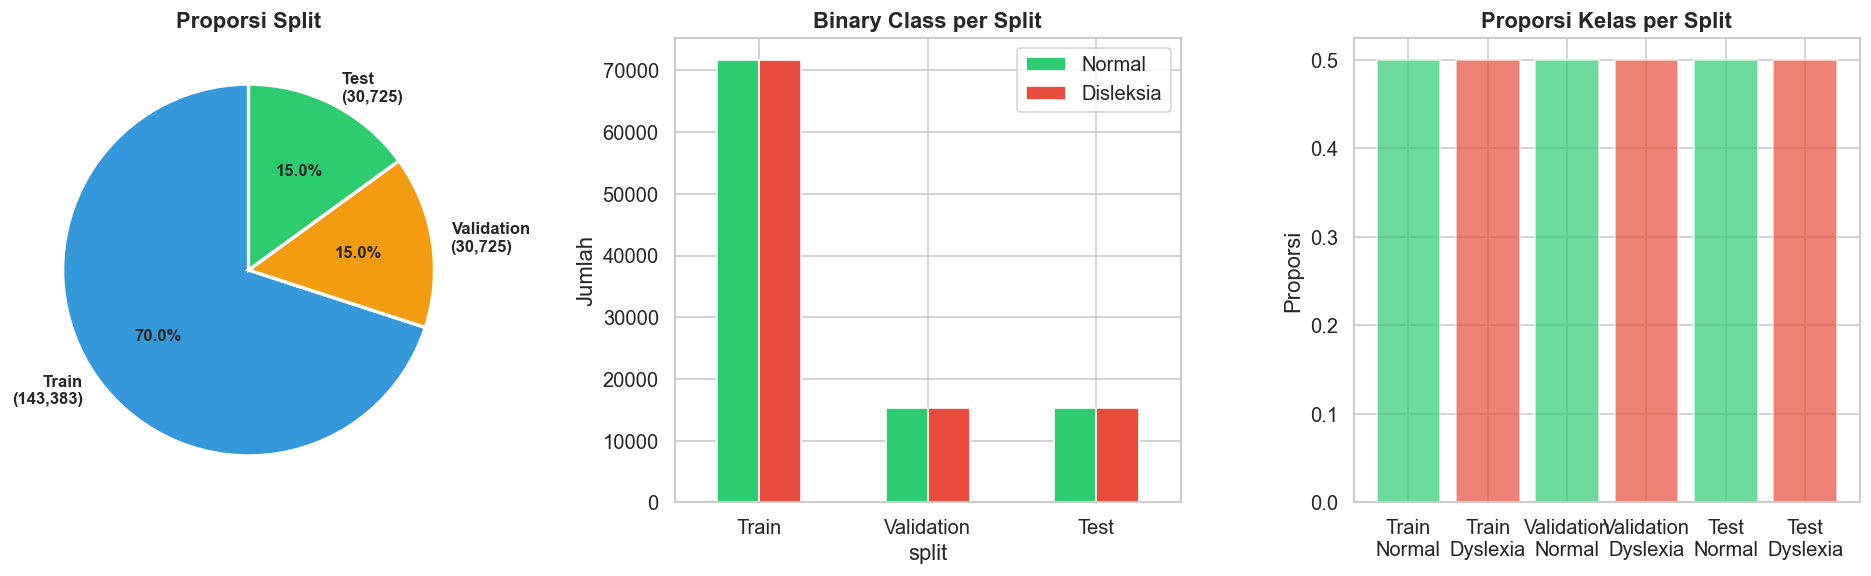

In [ ]:
fig = plt.figure(figsize=(16, 5))

ax1 = fig.add_subplot(1, 3, 1)
split_sizes = df_final['split'].value_counts().reindex(['Train','Validation','Test'])
ax1.pie(split_sizes, labels=[f'{s}\n({v:,})' for s,v in split_sizes.items()],
        colors=['#3498db','#f39c12','#2ecc71'], autopct='%1.1f%%', startangle=90,
        textprops={'fontsize':10,'fontweight':'bold'}, wedgeprops={'edgecolor':'white','linewidth':2})
ax1.set_title('Proporsi Split', fontweight='bold')

ax2 = fig.add_subplot(1, 3, 2)
bd = df_final.groupby(['split','target_class']).size().unstack(fill_value=0)
bd = bd.reindex(['Train','Validation','Test'])
bd.columns = ['Normal','Disleksia']
bd.plot(kind='bar', ax=ax2, color=['#2ecc71','#e74c3c'], edgecolor='white')
ax2.set_title('Binary Class per Split', fontweight='bold')
ax2.set_ylabel('Jumlah')
ax2.tick_params(axis='x', rotation=0)

ax3 = fig.add_subplot(1, 3, 3)
for split in ['Train','Validation','Test']:
    sub = df_final[df_final['split']==split]
    props = sub['target_class'].value_counts(normalize=True).sort_index()
    ax3.bar([f'{split}\nNormal', f'{split}\nDyslexia'],
            props.values, color=['#2ecc71','#e74c3c'], alpha=0.7)
ax3.set_title('Proporsi Kelas per Split', fontweight='bold')
ax3.set_ylabel('Proporsi')

plt.tight_layout()
plt.show()

### G. Kesimpulan Stratified Split

| Proses | Output | Status |
|---|---|---|
| A. Stratified Split | `master_dataset_final_balanced.csv` (70/15/15) | v |
| B. Build Struktur Folder | `Dataset/Gambo_balanced/Train/Validation/Test` | v |
| C. Rebuild CSV Final | `master_dataset_final_balanced_rill.csv` (sinkron dengan folder) | v |
| D. Verifikasi Integritas | CSV vs directory sinkron, nol missing file, nol leakage | v |
| E. Class Weights | `binary_weight_dict` + `severity_weight_dict` siap untuk AI Engineer | v |
| F. Validasi Visual | Dashboard split -- proporsi antar split konsisten (stratifikasi sukses) | v |

> Catatan Handover untuk AI Engineer:
> Gunakan `master_dataset_final_balanced_rill.csv` sebagai sumber data utama untuk training.
> Dataset ini **tidak menggunakan augmentasi fisik** -- augmentasi on-the-fly di `model.fit()` direkomendasikan.
> Gunakan `binary_weight_dict` dari Kode E sebagai parameter `class_weight` untuk menangani class imbalance yang fatal ini.


---
# Tahap 6: Feature Engineering (Side Quest)

Tahap ini mengekstrak **fitur turunan matematis** dari setiap gambar 28×28 piksel.
Alih-alih hanya menyerahkan matriks piksel mentah kepada AI Engineer, kita menghitung variabel-variabel tabular baru yang merepresentasikan **karakteristik goresan tulisan** secara numerik.

Fitur ini sangat berguna jika AI Engineer ingin membangun **Multi-Input Model** (Functional API) yang menggabungkan CNN (untuk gambar) dengan Dense Layer (untuk fitur tabular) secara bersamaan.

### Fitur yang Diekstrak (6 Fitur):
| Fitur | Deskripsi |
|---|---|
| `stroke_density` | Persentase piksel goresan terhadap total area gambar (784 piksel). Tulisan yang banyak dicoreng (over-tracing) memiliki kepadatan tinggi. |
| `center_of_mass_x` | Posisi titik tengah goresan pada sumbu horizontal (0-27). Huruf yang miring atau asimetris akan memiliki centroid yang melenceng. |
| `center_of_mass_y` | Posisi titik tengah goresan pada sumbu vertikal (0-27). |
| `bounding_box_ratio` | Rasio tinggi/lebar area goresan setelah whitespace dipangkas. Menangkap indikator proporsi huruf yang "gepeng" atau keluar batas. |
| `stroke_transitions` | Rata-rata jumlah transisi warna per baris horizontal. Indikator getaran/tremor tarikan garis. |
| `horizontal_symmetry` | Tingkat kesimetrisan antara belahan kiri dan kanan gambar. Indikator utama untuk mendeteksi pembalikan efek cermin (*Reversal*). |

### A. Load Data CSV

In [4]:
import pandas as pd
import numpy as np
from PIL import Image
import os

# === Konfigurasi ===
ROOT_DIR = r'Dataset/Gambo_Balanced'
CSV_INPUT = r'Scrap\Set Data\Hapus Putih\master_dataset_final_balanced_rill.csv'  # Output dari Tahap 5
CSV_OUTPUT = r'Scrap\Set Data\Hapus Putih\master_dataset_final_balanced_rill_featured.csv'
IMG_SIZE = 28
THRESHOLD = 128  # Piksel > 128 = putih (goresan), Piksel <= 128 = hitam (background)

df = pd.read_csv(CSV_INPUT)
print(f'Memuat {len(df):,} baris dari {CSV_INPUT}')
print(f'Kolom awal: {df.columns.tolist()}')

Memuat 156,453 baris dari Scrap\Set Data\Hapus Putih\master_dataset_final_balanced_rill.csv
Kolom awal: ['image_path', 'file_name', 'split', 'folder_category', 'severity_score', 'target_class']


### B. Pembuatan Fungsi Ekstraksi Fitur Geometri Tulisan Tangan

In [5]:
def extract_features(image_path):
    """
    Mengekstrak fitur geometri tulisan tangan
    dari gambar grayscale 28x28.

    Dataset:
    - tulisan = putih
    - background = hitam

    Returns:
        dict fitur numerik
    """

    try:

        # ====================================================
        # LOAD IMAGE
        # ====================================================

        img = (
            Image.open(image_path)
            .convert('L')
            .resize((28, 28))
        )

        pixels = np.array(
            img,
            dtype=np.float64
        )

        # ====================================================
        # BINARIZATION
        # ====================================================
        # putih = stroke/tulisan
        # hitam = background
        # pixel > 128 dianggap foreground
        # ====================================================

        binary = (
            pixels > THRESHOLD
        ).astype(np.float64)

        # ====================================================
        # BASIC INFO
        # ====================================================

        total_pixels = IMG_SIZE * IMG_SIZE

        stroke_sum = np.sum(binary)

        # ====================================================
        # 1. STROKE DENSITY
        # ====================================================

        stroke_density = (
            stroke_sum / total_pixels
        )

        # ====================================================
        # 2-3. CENTER OF MASS
        # ====================================================

        if stroke_sum > 0:

            y_coords, x_coords = np.where(
                binary == 1
            )

            center_x = np.mean(x_coords)

            center_y = np.mean(y_coords)

        else:

            center_x = IMG_SIZE / 2

            center_y = IMG_SIZE / 2

        # ====================================================
        # 4. BOUNDING BOX RATIO
        # ====================================================

        if stroke_sum > 0:

            rows_with_stroke = np.any(
                binary,
                axis=1
            )

            cols_with_stroke = np.any(
                binary,
                axis=0
            )

            height = np.sum(rows_with_stroke)

            width = np.sum(cols_with_stroke)

            # lebih stabil numerically
            bbox_ratio = (
                (height + 1)
                / (width + 1)
            )

        else:

            bbox_ratio = 1.0

        # ====================================================
        # 5. STROKE TRANSITIONS
        # ====================================================

        horizontal_transitions = 0

        for row in binary:

            diffs = np.abs(
                np.diff(row)
            )

            horizontal_transitions += np.sum(diffs)

        stroke_transitions = (
            horizontal_transitions / IMG_SIZE
        )

        # ====================================================
        # 6. HORIZONTAL SYMMETRY SCORE
        # ====================================================
        # mengukur kemiripan sisi kiri-kanan
        # semakin tinggi = semakin simetris
        # ====================================================

        left_half = binary[:, :14]

        right_half = binary[:, 14:]

        right_half_flipped = np.fliplr(
            right_half
        )

        symmetry_score = np.mean(
            left_half == right_half_flipped
        )

        # ====================================================
        # RETURN FEATURES
        # ====================================================

        return {

            'stroke_density': round(
                stroke_density,
                6
            ),

            'center_of_mass_x': round(
                center_x,
                4
            ),

            'center_of_mass_y': round(
                center_y,
                4
            ),

            'bounding_box_ratio': round(
                bbox_ratio,
                4
            ),

            'stroke_transitions': round(
                stroke_transitions,
                4
            ),

            'horizontal_symmetry': round(
                symmetry_score,
                6
            )
        }

    except Exception as e:

        return {

            'stroke_density': np.nan,

            'center_of_mass_x': np.nan,

            'center_of_mass_y': np.nan,

            'bounding_box_ratio': np.nan,

            'stroke_transitions': np.nan,

            'horizontal_symmetry': np.nan
        }

print('✅ Fungsi extract_features() siap digunakan.')

✅ Fungsi extract_features() siap digunakan.


### C. Eksekusi Ekstraksi Fitur pada Seluruh Dataset

In [6]:
# ============================================================
# FEATURE EXTRACTION
# ============================================================

features_list = []

errors = 0

print('\nMEMULAI FEATURE EXTRACTION...\n')

for i, row in df.iterrows():

    img_path = row['image_path']

    features = extract_features(
        img_path
    )

    features_list.append(features)

    # ========================================================
    # ERROR CHECK
    # ========================================================

    if np.isnan(
        features['stroke_density']
    ):

        errors += 1

    # ========================================================
    # PROGRESS
    # ========================================================

    if (i + 1) % 20000 == 0:

        print(
            f'Processed '
            f'{i+1:,}/{len(df):,}'
        )

# ============================================================
# GABUNG FEATURE
# ============================================================

df_features = pd.DataFrame(
    features_list
)

df_final = pd.concat(
    [
        df.reset_index(drop=True),
        df_features
    ],
    axis=1
)

# ============================================================
# FEATURE VALIDATION
# ============================================================

feature_cols = [
    'stroke_density',
    'center_of_mass_x',
    'center_of_mass_y',
    'bounding_box_ratio',
    'stroke_transitions',
    'horizontal_symmetry'
]

# ============================================================
# SUMMARY
# ============================================================

print('\n' + '=' * 60)
print('HASIL FEATURE ENGINEERING')
print('=' * 60)

print(f'\nKolom baru:')

for col in feature_cols:

    print(f'  - {col}')

print(f'\nTotal baris : {len(df_final):,}')

print(f'Error image : {errors:,}')

print(f'Shape akhir : {df_final.shape}')

# ============================================================
# NaN CHECK
# ============================================================

print('\n=== NaN CHECK ===')

nan_summary = (
    df_final[feature_cols]
    .isna()
    .sum()
)

print(nan_summary)

# ============================================================
# BASIC STATISTICS
# ============================================================

print('\n=== FEATURE STATISTICS ===')

print(
    df_final[feature_cols]
    .describe()
    .round(4)
)

# ============================================================
# PREVIEW
# ============================================================

print('\n=== SAMPLE DATA ===')

display(
    df_final.sample(
        min(5, len(df_final)),
        random_state=42
    )
)


MEMULAI FEATURE EXTRACTION...

Processed 20,000/156,453
Processed 40,000/156,453
Processed 60,000/156,453
Processed 80,000/156,453
Processed 100,000/156,453
Processed 120,000/156,453
Processed 140,000/156,453

HASIL FEATURE ENGINEERING

Kolom baru:
  - stroke_density
  - center_of_mass_x
  - center_of_mass_y
  - bounding_box_ratio
  - stroke_transitions
  - horizontal_symmetry

Total baris : 156,453
Error image : 0
Shape akhir : (156453, 12)

=== NaN CHECK ===
stroke_density         0
center_of_mass_x       0
center_of_mass_y       0
bounding_box_ratio     0
stroke_transitions     0
horizontal_symmetry    0
dtype: int64

=== FEATURE STATISTICS ===
       stroke_density  center_of_mass_x  center_of_mass_y  bounding_box_ratio  \
count     156453.0000       156453.0000       156453.0000         156453.0000   
mean           0.1436           13.1518           13.3575              1.0749   
std            0.0456            1.1472            1.1405              0.2561   
min            0.01

,image_path,file_name,split,folder_category,severity_score,target_class,stroke_density,center_of_mass_x,center_of_mass_y,bounding_box_ratio,stroke_transitions,horizontal_symmetry
62171,Dataset\Gambo_Balanced\Train\Corrected\Train_C...,Train_Corrected_3_02993.png,Train,Corrected,3,1,0.139031,13.1743,15.0459,1.0000,2.3571,0.823980
12494,Dataset\Gambo_Balanced\Test\Normal\Test_Normal...,Test_Normal_A-1021.png,Test,Normal,0,0,0.141582,14.7387,13.6937,1.1053,2.5714,0.793367
21885,Dataset\Gambo_Balanced\Test\Reversal\Test_Reve...,Test_Reversal_6_03996.png,Test,Reversal,6,1,0.088010,13.7971,14.7101,1.6667,2.0000,0.895408
115674,Dataset\Gambo_Balanced\Train\Reversal\Train_Re...,Train_Reversal_6_08715.png,Train,Reversal,6,1,0.094388,14.8649,14.9595,0.7500,1.2143,0.867347
63316,Dataset\Gambo_Balanced\Train\Corrected\Train_C...,Train_Corrected_3_04138.png,Train,Corrected,3,1,0.082908,13.8000,11.0923,0.9000,1.9286,0.844388


### D. Validasi Statistik Fitur Baru

Memvalidasi bahwa fitur-fitur yang diekstrak memiliki **distribusi yang bermakna** dan berbeda antara kelas Normal vs Disleksia.

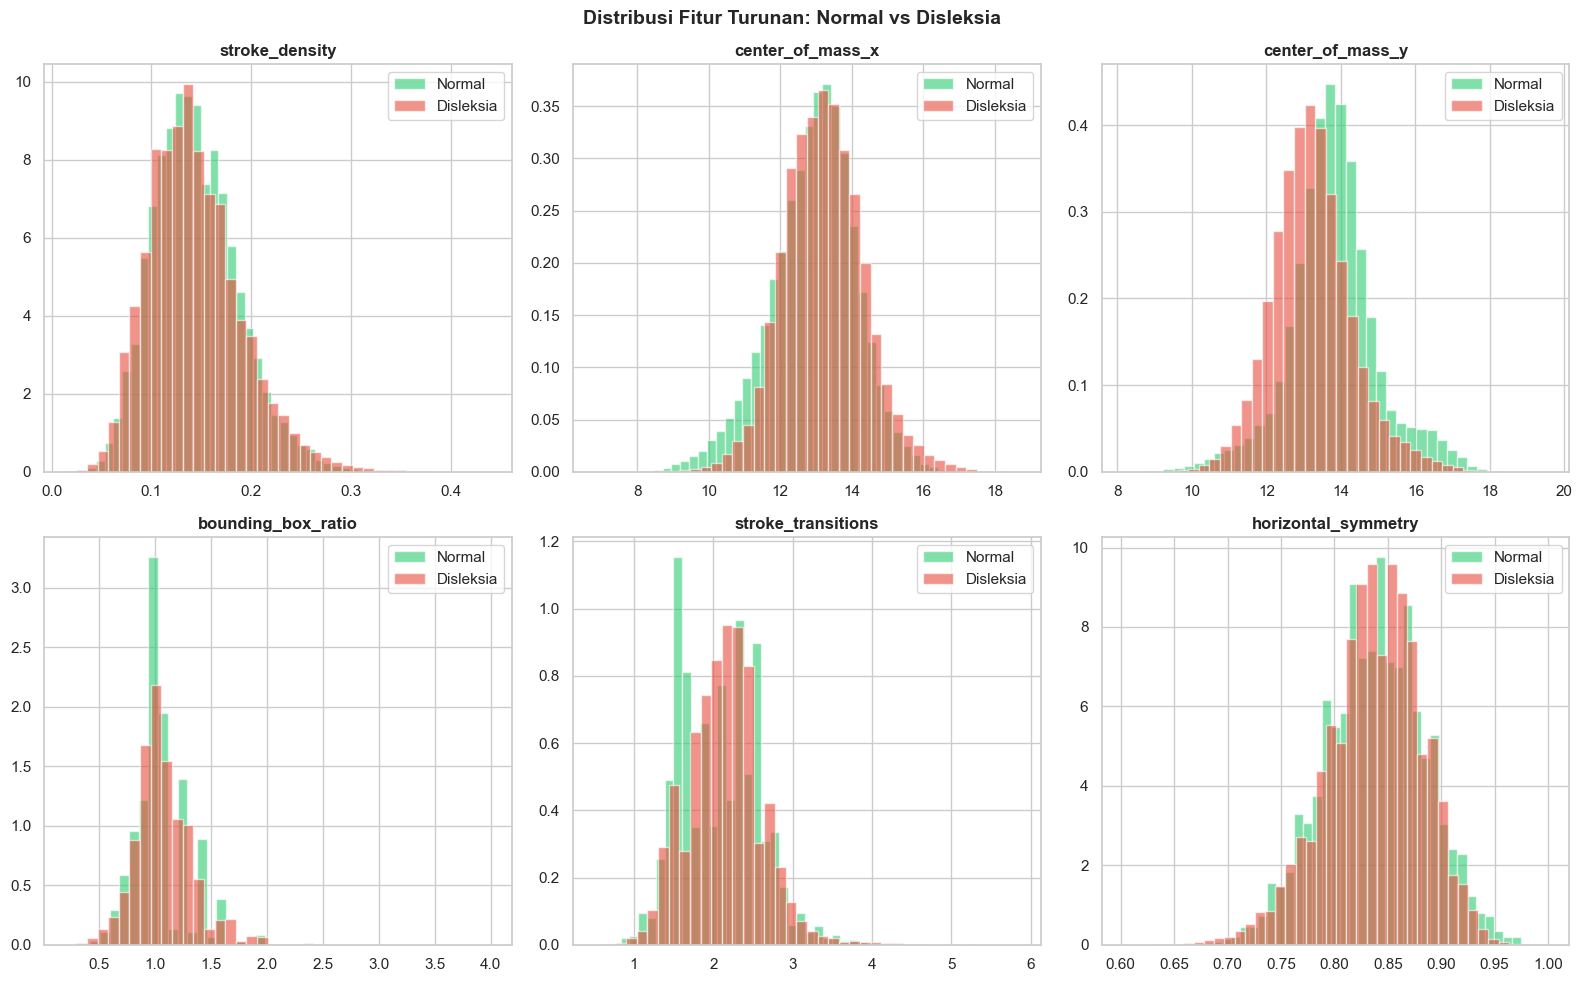

Grafik distribusi fitur tersimpan di assets/feature_engineering_distribution.png


In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='whitegrid')

feature_cols = [
    'stroke_density',
    'center_of_mass_x',
    'center_of_mass_y',
    'bounding_box_ratio',
    'stroke_transitions',
    'horizontal_symmetry'
]

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Distribusi Fitur Turunan: Normal vs Disleksia', fontsize=14, fontweight='bold')

for idx, feat in enumerate(feature_cols):
    ax = axes[idx // 3][idx % 3]
    for label, color, name in [(0, '#2ECC71', 'Normal'), (1, '#E74C3C', 'Disleksia')]:
        subset = df_final[df_final['target_class'] == label][feat].dropna()
        ax.hist(subset, bins=40, alpha=0.6, color=color, label=name, density=True)
    ax.set_title(feat, fontweight='bold')
    ax.legend()

plt.tight_layout()
plt.savefig('../assets/feature_engineering_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Grafik distribusi fitur tersimpan di assets/feature_engineering_distribution.png')

> **Insight:** Distribusi histogram di atas memperlihatkan adanya perbedaan pola sebaran data antara tulisan `Normal` dan `Disleksia`. Fitur seperti *Stroke Density* dan *Stroke Transitions* pada kelas disleksia cenderung bergeser ke arah kanan (nilai lebih tinggi), memvalidasi secara statistik karakteristik keraguan, getaran (tremor), dan ketebalan garis yang berulang pada coretan penderita disleksia.

### E. Ringkasan Statistik per Kelas

In [11]:
# === Ringkasan Statistik per Kelas ===
print('=== Rata-rata Fitur per Kelas ===')
summary = df_final.groupby('target_class')[feature_cols].mean()
summary.index = ['Normal (0)', 'Disleksia (1)']
print(summary.round(4).to_string())

print('\n=== Selisih Absolut (Disleksia - Normal) ===')
diff = summary.loc['Disleksia (1)'] - summary.loc['Normal (0)']
print(diff.round(4).to_string())
print('\nFitur dengan selisih terbesar menunjukkan potensi diskriminatif tertinggi untuk model AI.')

=== Rata-rata Fitur per Kelas ===
               stroke_density  center_of_mass_x  center_of_mass_y  bounding_box_ratio  stroke_transitions  horizontal_symmetry
Normal (0)             0.1444           12.9243           13.7955              1.0597              2.0694               0.8378
Disleksia (1)          0.1434           13.2197           13.2267              1.0794              2.1472               0.8368

=== Selisih Absolut (Disleksia - Normal) ===
stroke_density        -0.0010
center_of_mass_x       0.2954
center_of_mass_y      -0.5689
bounding_box_ratio     0.0197
stroke_transitions     0.0778
horizontal_symmetry   -0.0011

Fitur dengan selisih terbesar menunjukkan potensi diskriminatif tertinggi untuk model AI.


### F. Simpan Dataset Final + Fitur Turunan

In [13]:
# === Simpan CSV dengan kolom fitur baru ===
df_final.to_csv(CSV_OUTPUT, index=False)
print(f'Dataset tersimpan: {CSV_OUTPUT}')
print(f'Kolom final: {df_final.columns.tolist()}')
print(f'Total baris: {len(df_final):,}')
print('\nData Dictionary Fitur Baru:')
print('  stroke_density      : Kepadatan stroke/tulisan putih.')
print('  center_of_mass_x    : Titik pusat stroke sumbu-X.')
print('  center_of_mass_y    : Titik pusat stroke sumbu-Y.')
print('  bounding_box_ratio  : Rasio tinggi/lebar area tulisan.')
print('  stroke_transitions  : Kompleksitas transisi stroke horizontal.')
print('  horizontal_symmetry : Tingkat simetri kiri-kanan tulisan.')

Dataset tersimpan: Scrap\Set Data\Hapus Putih\master_dataset_final_balanced_rill_featured.csv
Kolom final: ['image_path', 'file_name', 'split', 'folder_category', 'severity_score', 'target_class', 'stroke_density', 'center_of_mass_x', 'center_of_mass_y', 'bounding_box_ratio', 'stroke_transitions', 'horizontal_symmetry']
Total baris: 156,453

Data Dictionary Fitur Baru:
  stroke_density      : Kepadatan stroke/tulisan putih.
  center_of_mass_x    : Titik pusat stroke sumbu-X.
  center_of_mass_y    : Titik pusat stroke sumbu-Y.
  bounding_box_ratio  : Rasio tinggi/lebar area tulisan.
  stroke_transitions  : Kompleksitas transisi stroke horizontal.
  horizontal_symmetry : Tingkat simetri kiri-kanan tulisan.


### G. Kesimpulan Feature Engineering

| Proses | Output | Status |
|---|---|---|
| A. Load CSV | Data dari Tahap 5 | ✅ |
| B. Ekstraksi Matematis | 6 fitur diekstrak dari gambar 28x28 (Thresholding, Bounding Box, COM, dll) | ✅ |
| C. Penggabungan Fitur | DataFrame awal digabung dengan 6 kolom fitur | ✅ |
| D & E. Validasi Statistik | Grafik distribusi fitur dan selisih absolut antar kelas tersimpan | ✅ |
| F. Simpan Final Dataset | `master_dataset_final_balanced_rill_featured.csv` | ✅ |

> 📌 **Catatan Handover untuk AI Engineer:**
> Tahap 6 ini menyiapkan **Late Fusion / Multi-Modal architecture** ready dataset.
> Selain melakukan klasifikasi berbasis CNN menggunakan `image_path`, Anda juga dapat membuat _branch_ tambahan berbasis Dense layer untuk mengonsumsi ke-6 fitur ini guna menambah rasionalisasi klinis pada prediksi model AI.

---
# Tahap 7: Kesiapan Data untuk Pemodelan

Tahap terakhir — memastikan dataset siap diserahkan ke AI Engineer.

### A. Data Dictionary

Definisi formal setiap kolom dalam `master_dataset_final.csv`:

| Kolom | Tipe Data | Deskripsi | Nilai |
|---|---|---|---|
| `image_path` | String | Path absolut/relatif ke file gambar `.png` | Contoh: `Dataset/Gambo_balanced/Train/...` |
| `file_name` | String | Nama file gambar fisik | Contoh: `Train_Normal_A-3.png` |
| `split` | String | Pembagian dataset | `Train`, `Validation`, `Test` |
| `folder_category` | String | Kategori kelas asal | `Normal`, `Corrected`, `Reversal` |
| `severity_score` | Integer | Skor keparahan (setelah normalisasi) | `0` = Normal, `1`–`6` = Ringan–Parah |
| `target_class` | Integer | Label target biner | `0` = Normal, `1` = Disleksia |
| `stroke_density` | Float | Fitur matematis: Kepadatan goresan putih | `0.0` - `1.0` |
| `center_of_mass_x` | Float | Fitur matematis: Pusat koordinat X | `0.0` - `28.0` |
| `center_of_mass_y` | Float | Fitur matematis: Pusat koordinat Y | `0.0` - `28.0` |
| `bounding_box_ratio` | Float | Fitur matematis: Rasio Tinggi/Lebar tulisan | `0.0` - `∞` |
| `stroke_transitions` | Float | Fitur matematis: Transisi warna per baris | `0.0` - `28.0` |
| `horizontal_symmetry`| Float | Fitur matematis: Simetri belahan kiri-kanan | `0.0` - `1.0` |

### Aturan untuk AI Engineer

| Aturan | Penjelasan |
|---|---|
| **Input model utama** | Matriks piksel gambar dari `image_path` |
| **Input model sekunder**| 6 fitur matematis di atas (Opsional untuk *Late Fusion*) |
| **Output utama** | `target_class` (klasifikasi biner) |
| **Output sekunder** | `severity_score` (multi-class) |
| **JANGAN sebagai fitur** | `severity_score`, `folder_category`, `file_name` — data leakage |
| **Format gambar** | Grayscale, 28×28 piksel, `.png` |
| **Horizontal Flip** | ❌ DILARANG — mengubah `b` menjadi `d` |

### B. Validasi Akhir

In [ ]:
import pandas as pd

# ============================================================
# LOAD FINAL CSV
# ============================================================

CSV_OUTPUT = 'master_dataset_final_balanced_rill_featured.csv'

df_check = pd.read_csv(CSV_OUTPUT)

# ============================================================
# BASIC INFO
# ============================================================

print('=== VALIDASI AKHIR DATASET ===')

print(f'Total baris: {len(df_check):,}')

print(f'Kolom: {list(df_check.columns)}')

# ============================================================
# SPLIT PROPORTION
# ============================================================

total = len(df_check)

print('\n=== PROPORSI SPLIT ===')

for split in ['Train', 'Validation', 'Test']:

    n = len(
        df_check[df_check['split'] == split]
    )

    print(
        f'{split:12s}: {n:>8,} gambar ({n/total*100:5.1f}%)'
    )

# ============================================================
# DATA LEAKAGE CHECK
# ============================================================

train_paths = set(
    df_check[
        df_check['split'] == 'Train'
    ]['image_path']
)

val_paths = set(
    df_check[
        df_check['split'] == 'Validation'
    ]['image_path']
)

test_paths = set(
    df_check[
        df_check['split'] == 'Test'
    ]['image_path']
)

train_val_overlap = len(
    train_paths & val_paths
)

train_test_overlap = len(
    train_paths & test_paths
)

val_test_overlap = len(
    val_paths & test_paths
)

print('\n=== CEK DATA LEAKAGE ===')

print(f'Train ∩ Validation : {train_val_overlap}')

print(f'Train ∩ Test       : {train_test_overlap}')

print(f'Validation ∩ Test  : {val_test_overlap}')

# ============================================================
# FINAL STATUS
# ============================================================

if (
    train_val_overlap == 0
    and train_test_overlap == 0
    and val_test_overlap == 0
):

    print('\n✅ AMAN — Tidak ada data leakage antar split.')

else:

    print('\n⚠️ PERINGATAN — Ditemukan overlap antar split.')

print('\n✅ Dataset siap untuk handover ke AI Engineer.')

=== VALIDASI AKHIR DATASET ===
Total baris: 156,453
Kolom: ['image_path', 'file_name', 'split', 'folder_category', 'severity_score', 'target_class']

=== PROPORSI SPLIT ===
Train       :  109,517 gambar ( 70.0%)
Validation  :   23,468 gambar ( 15.0%)
Test        :   23,468 gambar ( 15.0%)

=== CEK DATA LEAKAGE ===
Train ∩ Validation : 0
Train ∩ Test       : 0
Validation ∩ Test  : 0

✅ AMAN — Tidak ada data leakage antar split.

✅ Dataset siap untuk handover ke AI Engineer.


### C. Kompresi Dataset
Kompilasi folder `Dataset/Gambo` menjadi `.zip` agar mudah dibagikan kepada kolega.

In [2]:
import shutil
import os

folder_to_zip = 'Dataset/Gambo_Balanced'
output_zip = 'Dataset_Gambo_hapusPutih'

if os.path.exists(folder_to_zip):
    print(f"Mengompresi {folder_to_zip} menjadi {output_zip}.zip...")
    shutil.make_archive(output_zip, 'zip', folder_to_zip)
    print("✅ Selesai! File zip berhasil dibuat di direktori saat ini.")
else:
    print(f"❌ Folder {folder_to_zip} tidak ditemukan!")


Mengompresi Dataset/Gambo_Balanced menjadi Dataset_Gambo_hapusPutih.zip...
✅ Selesai! File zip berhasil dibuat di direktori saat ini.


### D. Konversi Dataset Uji ke Format Pixel Vektor

In [1]:
import pandas as pd
import numpy as np
from PIL import Image
import os

# Target CSV
CSV_SRC = r'd:\Tugas\Kuliah\Semester 6\Dicoding\Capstone Project\Dataset Disleksia\csv_metadata\Dataset_Dyslexia_NoAugmentation_FeatureEngineering.csv'
# Target Output
OUTPUT = r'd:\Tugas\Kuliah\Semester 6\Dicoding\Capstone Project\Dataset Disleksia\csv_metadata\dyslexialens_test_noAugmentation.csv.gz'
ROOT_DIR = r'd:\Tugas\Kuliah\Semester 6\Dicoding\Capstone Project\Dataset Disleksia\notebooks'

df = pd.read_csv(CSV_SRC)
test_df = df[df['split'] == 'Test'].copy()
print(f'Test images to process: {len(test_df):,}')

rows = []
errors = 0
for i, (_, row) in enumerate(test_df.iterrows()):
    img_path = row['image_path']
    # Check if absolute path
    if not os.path.exists(img_path):
        img_path = os.path.join(ROOT_DIR, row['image_path'])
        
    if not os.path.exists(img_path):
        errors += 1
        continue

    try:
        img = Image.open(img_path).convert('L').resize((28, 28))
        pixels = np.array(img, dtype=np.uint8).flatten()
        pixel_row = [int(row['target_class'])] + pixels.tolist()
        rows.append(pixel_row)
    except Exception as e:
        errors += 1
        print(f"Error reading {img_path}: {e}")

    if (i + 1) % 5000 == 0:
        print(f'  Processed {i+1:,}/{len(test_df):,}...')

# Build DataFrame
print("Building dataframe...")
cols = ['label'] + [f'pixel{i}' for i in range(784)]
df_out = pd.DataFrame(rows, columns=cols)
df_out = df_out.astype(np.uint8)

# Save compressed
print("Compressing and saving to disk...")
df_out.to_csv(OUTPUT, index=False, compression='gzip')
size_mb = os.path.getsize(OUTPUT) / (1024 * 1024)
print(f'\nDone! {OUTPUT} ({size_mb:.1f} MB)')
print(f'Total images: {len(df_out):,} | Errors: {errors}')
print(df_out['label'].value_counts().rename({0:'Normal', 1:'Disleksia'}))

Test images to process: 23,468
  Processed 5,000/23,468...
  Processed 10,000/23,468...
  Processed 15,000/23,468...
  Processed 20,000/23,468...
Building dataframe...
Compressing and saving to disk...

Done! d:\Tugas\Kuliah\Semester 6\Dicoding\Capstone Project\Dataset Disleksia\csv_metadata\dyslexialens_test_noAugmentation.csv.gz (6.1 MB)
Total images: 23,468 | Errors: 0
label
Disleksia    18069
Normal        5399
Name: count, dtype: int64


### Kesimpulan Pipeline Data Scientist

| Tahap | Output | Status |
|---|---|---|
| 1. Assessing Data | Audit distribusi, resolusi, anomali | ✅ |
| 2. Physical Renaming | Normalisasi skala severity 1–6 | ✅ (Opsional) |
| 3. Cleaning Data | `master_dataset_dyslexia.csv` (180.726 baris) | ✅ |
| 4. EDA + Explanatory | Visualisasi distribusi, heatmap, jawaban bisnis | ✅ |
| 5. Stratified Split | Train/Validation/Test (stratified by severity) | ✅ |
| 6. Kesiapan Data | Data Dictionary + class weights + rekomendasi | ✅ |

**File output untuk AI Engineer:**

| File | Deskripsi |
|---|---|
| `master_dataset_final_balanced_rill_featured.csv` | *Single Source of Truth* — Metadata lengkap, path bersih, dan 6 fitur matematis |
| `Dataset_Gambo_Original_balanced.zip` | Arsip seluruh gambar `.png` yang siap diekstrak dan di-load |
| `dyslexialens_test_noAugmentation.csv.gz` | (Opsional) Representasi piksel rata untuk pengujian cepat tanpa *loader* |

**Handover ke AI Engineer:**
1. Gunakan `master_dataset_final_balanced_rill_featured.csv` sebagai *single source of truth*.
2. Dataset ini sangat **tidak seimbang (balanced)**. Karena tidak ada augmentasi fisik, Anda **wajib** menangani ketimpangan ini saat training.
3. Gunakan `binary_weight_dict` (dari Tahap 5E) sebagai argumen `class_weight` di `model.fit()`.
4. Jika memungkinkan, eksplorasi arsitektur **Late Fusion**: gabungkan *output* CNN (dari `image_path`) dengan Dense Layer (berisi 6 fitur tabular) sebelum *layer* klasifikasi akhir.
5. Evaluasi model difokuskan pada **F1-Score** dan **Recall**, bukan sekadar Accuracy.
6. ❌ **JANGAN** pernah menggunakan *Horizontal Flip* saat augmentasi *on-the-fly*, karena ini akan merusak makna huruf (menjadikan Normal tampak seperti *Reversal*).